# Sistema Analítico de Facturas Electrónicas

Orquesta los scripts del trabajo y muestra la salida de cada paso.

Flujo: OCR (`extraer_facturas.py`) -> pre-etiquetado Qwen -> preparar dataset (`preparar_dataset_kie.py`) -> inspeccion.

> Pensado para correr en VPS (g2-standard-4, GPU NVIDIA L4 24GB, 4 vCPU, 16 GB RAM, Ubuntu 22.04).

> Decisiones de alcance. Solo facturas electrónicas de venta (FEV). 8 campos KIE; CUFE y QR se resuelven sin OCR e ID por contador. Las decisiones de diseño quedan anotadas en recuadros de decisión a lo largo del notebook, en línea con el documento de tesis.

## Entornos virtuales

El Jupyter se lanza desde `venv_kie` (PyTorch + Transformers), por lo que casi todas las celdas corren en `venv_kie`. Las únicas excepciones son el Paso 1 (OCR) y el Paso 2 (pre-etiquetado), que necesitan el venv de PaddleOCR/Ollama y no corren en el kernel `venv_kie` (ya están ejecutados). Cada sección indica su entorno al final de su celda de texto.

- `venv_kie` — EDA, entrenamiento, evaluación, mejoras, validación, inferencia.
- `venv` (PaddleOCR) — solo Paso 1 (OCR) y Paso 2 (pre-etiquetado); ya hechos.

## 1. Configuracion

Rutas y parametros. Ajusta `BASE`, `LS_JSON` y `DEVICE` segun tu entorno.

El notebook separa dos tipos de celdas. Las de construccion del modelo (OCR, pre-etiquetado, construccion del dataset, entrenamiento y validacion cruzada) se ejecutan una sola vez y dejan su salida en disco; las de produccion aplican el modelo ya entrenado sobre las facturas (inferencia y validacion por campo). Para no repetir procesos largos, esas celdas empiezan con un parametro `FORZAR`: con `FORZAR = 0` la celda detecta que la salida ya existe, muestra un aviso y la reutiliza sin volver a ejecutarse; con `FORZAR = 1` vuelve a ejecutar el proceso (re-OCR, reentrenar, regenerar). La deteccion la hace la funcion `salida_construccion`, definida en la celda siguiente.

> **Entorno: `venv_kie`**

In [29]:
import os, json, subprocess, sys, glob, re
from pathlib import Path
from collections import Counter, defaultdict
import numpy as np, pandas as pd
import matplotlib.pyplot as plt

# === Rutas (ajusta a tu entorno: VPS o local) ===
BASE           = os.path.expanduser('~/agente-documentos')
FACTURAS_DIR   = f'{BASE}/facturas'                  # imagenes/PDF de entrada
OCR_DIR        = f'{BASE}/facturas_ocr'              # tokens OCR (salida Paso 1)
LS_JSON        = f'{BASE}/label_studio_import.json'  # TU anotacion de Label Studio
ETIQ_DIR       = f'{BASE}/facturas_etiquetadas'      # pre-etiquetado (salida Paso 2)
ETIQ_EDA_DIR   = f'{BASE}/facturas_etiquetadas_eda'  # re-corrida de Qwen SOLO para el EDA (no toca el gold)
DATASET_DIR    = f'{BASE}/dataset_kie'               # dataset KIE (salida Paso 3)
DB_FACTURAS    = f'{BASE}/db_facturas.csv'           # BD de referencia (cruce capa B, por CUFE)
DEVICE         = 'gpu'        # 'gpu' en el VPS, 'cpu' si no hay GPU
N_TEST_LAYOUTS = 6           # layouts reservados para test (split por layout)
# layout = emisor. Esta regex agrupa tanto 1 pagina (layout_08_014) como
# multipagina (layout_09_014_p1 / _p2) bajo el mismo emisor (layout_09),
# evitando que las paginas de una factura caigan en train y test a la vez.
LAYOUT_REGEX   = r'(layout_\d+)_'

# Estilo de los graficos del EDA
plt.rcParams.update({'figure.dpi': 110, 'axes.titlesize': 10, 'axes.grid': True, 'grid.alpha': 0.3})

def run(cmd):
    cmd = [str(c) for c in cmd]
    print('$ ' + ' '.join(cmd))
    p = subprocess.run(cmd)
    print('[exit code: ' + str(p.returncode) + ']')
    return p.returncode

def salida_construccion(salida, forzar=0, que='este paso', fase='construccion'):
    """Control de re-ejecucion de los procesos que se corren una sola vez
    (OCR, pre-etiquetado, dataset, entrenamiento, validacion cruzada, inferencia).

    'salida' es la ruta -o lista de rutas- que el proceso genera; un elemento con '*'
    se trata como patron glob que debe encontrar al menos un archivo. Devuelve True
    cuando la salida ya existe y forzar==0: en ese caso imprime un aviso y la celda no
    debe volver a ejecutar el proceso (se reutiliza el resultado guardado). Devuelve
    False cuando hay que ejecutar (la salida aun no existe, o forzar==1)."""
    rutas = [salida] if isinstance(salida, (str, Path)) else list(salida)
    def _hay(r):
        r = str(r)
        return bool(glob.glob(r)) if '*' in r else os.path.exists(r)
    if forzar or not all(_hay(r) for r in rutas):
        return False
    print(f'[Salida ya generada -- fase de {fase}. No se vuelve a ejecutar.]')
    print(f'Se reutiliza el resultado de {que}:')
    for r in rutas:
        print('   -', r)
    print('Para volver a ejecutar este proceso, cambia FORZAR de 0 a 1 en esta celda.')
    return True

print('Config lista. BASE =', BASE)

Config lista. BASE = /home/jperezv/agente-documentos


---
# PARTE I · Los datos: de la imagen al dataset

Esta primera parte recorre el camino que va de la factura en crudo al dataset listo para entrenar, con tres análisis exploratorios (EDA): la base de referenci* contra la que se validará (EDA 1), el texto que produce el OCR (EDA 2) y el balance del dataset ya particionado por emisor (EDA 3). Un cuarto EDA, sobre los resultados del modelo en producción, cierra el notebook.

## 2. EDA 1 · Base de referencia `db_facturas.csv`

La validación final cruza cada campo extraído contra una base de referencia (que hace las veces de la base de la DIAN). Antes de confiar en ella, la exploramos: qué tan completa está cada columna, si las llaves (NUMERO_FACTURA, CUFE) son únicas, y cómo se distribuyen montos, fechas y ciudades. Son facturas reales enmascaradas por *data masking*: conservan formato y estructura, pero sus identidades son sintéticas.

> **Decisión — data masking.** Las facturas son reales pero enmascaradas (identidades sintéticas que conservan formato y estructura). No afecta el KIE (aprende posición y formato, no identidades).

> **Entorno: `venv_kie`**

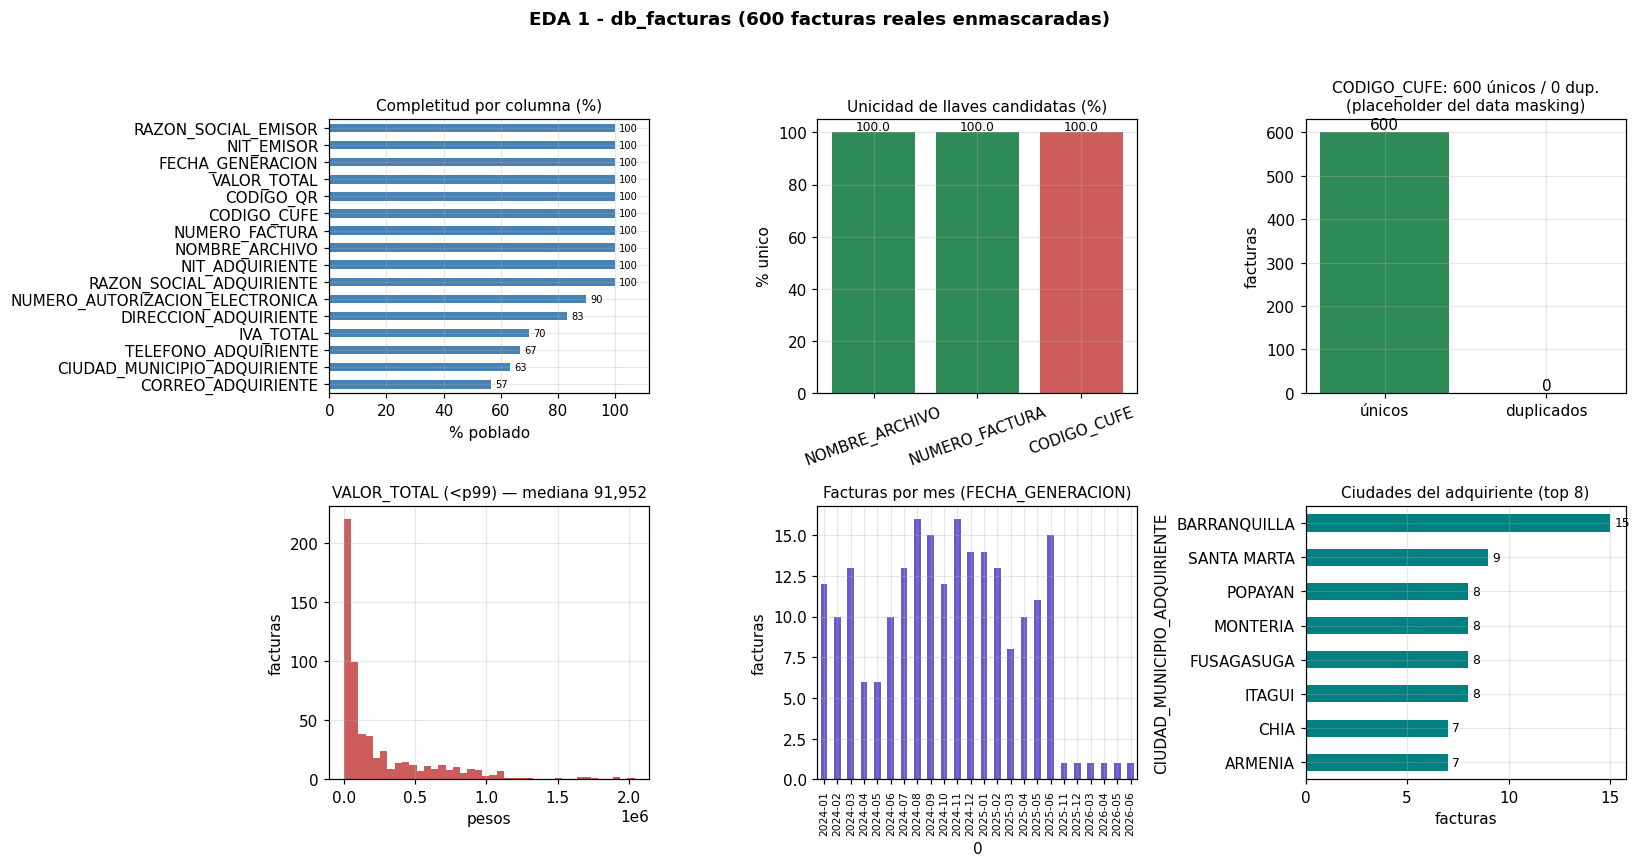

In [36]:
# ===== EDA 1 — db_facturas.csv (todo en gráficos) =====
df = pd.read_csv(DB_FACTURAS, sep=';', dtype=str, encoding='utf-8-sig', keep_default_na=False)

def _alnum(s):
    return re.sub(r'[^0-9a-z]', '', (s or '').lower())

def _monto(s):
    s = re.sub(r'[^\d.,]', '', s or '')
    if not s:
        return np.nan
    if ',' in s and '.' in s:
        s = s.replace('.', '').replace(',', '.') if s.rfind(',') > s.rfind('.') else s.replace(',', '')
    elif ',' in s:
        s = s.replace(',', '')
    try:
        return float(s)
    except ValueError:
        return np.nan

pobl = (~(df.eq('') | df.eq('null'))).mean().mul(100).sort_values()
llaves = {k: df[k].map(_alnum).replace('', np.nan).nunique() / len(df) * 100
          for k in ['NOMBRE_ARCHIVO', 'NUMERO_FACTURA', 'CODIGO_CUFE']}
vt = df['VALOR_TOTAL'].map(_monto).dropna()
fch = pd.to_datetime(df['FECHA_GENERACION'].str.extract(r'(\d{1,2}[/-]\d{1,2}[/-]\d{4})')[0],
                     dayfirst=True, errors='coerce').dropna()
ciud = df['CIUDAD_MUNICIPIO_ADQUIRIENTE'].str.upper().replace('', np.nan).dropna().value_counts().head(8)
cufe_u = df['CODIGO_CUFE'].nunique(); cufe_d = len(df) - cufe_u

fig, ax = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle('EDA 1 - db_facturas (600 facturas reales enmascaradas)', fontweight='bold')

pobl.plot.barh(ax=ax[0, 0], color='steelblue'); ax[0, 0].set_title('Completitud por columna (%)'); ax[0, 0].set_xlim(0, 112); ax[0, 0].set_xlabel('% poblado')
for _y, _v in enumerate(pobl.values):
    ax[0, 0].text(_v + 1.5, _y, f'{_v:.0f}', va='center', fontsize=6.5)

ax[0, 1].bar(list(llaves), list(llaves.values()), color=['seagreen', 'seagreen', 'indianred'])
ax[0, 1].set_ylim(0, 105); ax[0, 1].set_title('Unicidad de llaves candidatas (%)'); ax[0, 1].set_ylabel('% unico'); ax[0, 1].tick_params(axis='x', rotation=20)
for i, v in enumerate(llaves.values()):
    ax[0, 1].text(i, v + 1, f'{v:.1f}', ha='center', fontsize=8)

ax[0, 2].bar(['únicos', 'duplicados'], [cufe_u, cufe_d], color=['seagreen', 'indianred'])
ax[0, 2].set_title(f'CODIGO_CUFE: {cufe_u} únicos / {cufe_d} dup.\n(placeholder del data masking)')
ax[0, 2].set_ylabel('facturas'); ax[0, 2].bar_label(ax[0, 2].containers[0])

vt[vt < vt.quantile(0.99)].plot.hist(bins=40, ax=ax[1, 0], color='indianred')
ax[1, 0].set_title(f'VALOR_TOTAL (<p99) — mediana {vt.median():,.0f}'); ax[1, 0].set_xlabel('pesos'); ax[1, 0].set_ylabel('facturas')

fch.dt.to_period('M').value_counts().sort_index().plot.bar(ax=ax[1, 1], color='slateblue')
ax[1, 1].set_title('Facturas por mes (FECHA_GENERACION)'); ax[1, 1].set_ylabel('facturas'); ax[1, 1].tick_params(axis='x', rotation=90, labelsize=7)

ciud.sort_values().plot.barh(ax=ax[1, 2], color='teal'); ax[1, 2].set_title('Ciudades del adquiriente (top 8)'); ax[1, 2].set_xlabel('facturas')
for _y, _v in enumerate(ciud.sort_values().values):
    ax[1, 2].text(_v + 0.2, _y, str(_v), va='center', fontsize=8)

plt.tight_layout(rect=[0, 0, 1, 0.96]); plt.show()


### 2.1 EDA — Base de referencia `db_facturas` (vista rápida en texto)

Exploramos la base de referencia contra la que se cruzan las facturas extraídas (`db_facturas.csv`). Es la fuente de verdad de la capa B de validación (cruce por `CUFE`).

> **Nota - data masking.** Las facturas de este proyecto son reales, sus datos sensibles (NIT, nombres/razón social, números de factura, CUFE) fueron enmascarados (data masking) por motivos legales antes de su uso. El enmascaramiento conserva el formato y la estructura del dato original, por lo que no afecta el análisis ni el aprendizaje KIE que dependen de la posición y el formato, no de la identidad concreta.

> **Entorno: `venv_kie`**

In [3]:
# EDA de la base de referencia db_facturas (600 facturas REALES, enmascaradas por data masking).
import pandas as pd, numpy as np, re
import matplotlib.pyplot as plt
from IPython.display import display

df = pd.read_csv(DB_FACTURAS, sep=';', dtype=str, encoding='utf-8-sig', keep_default_na=False)
print(f'db_facturas: {df.shape[0]} filas x {df.shape[1]} columnas  ({DB_FACTURAS})')
print('Columnas:', list(df.columns))

# --- Completitud por columna (% poblado) ---
poblado = (~(df.eq('') | df.eq('null'))).mean().mul(100).round(1).sort_values(ascending=False)
print('\n=== Completitud por columna (% poblado) ===')
display(poblado.to_frame('% poblado'))

# --- Identificador de respaldo: NUMERO_FACTURA (la llave del cruce es el CUFE) ---
nf = df['NUMERO_FACTURA'].map(lambda s: re.sub(r'[^0-9a-z]', '', (s or '').lower()))
nf_ok = nf[nf != '']
print(f'NUMERO_FACTURA: {nf_ok.nunique()} unicos de {len(nf_ok)} no vacios '
      f'({nf_ok.nunique()/max(len(nf_ok),1)*100:.1f}% unico) -> identificador de respaldo (el cruce es por CUFE)')

# --- CUFE: llave del cruce (unico; el data masking solo lo vuelve no verificable) ---
top_cufe = df['CODIGO_CUFE'].value_counts().head(5)
print(f'\n=== CODIGO_CUFE ({df["CODIGO_CUFE"].nunique()} valores unicos de {len(df)}) ===')
print('(CUFE unico en las 600 filas -> es la LLAVE del cruce; el data masking solo lo vuelve no verificable criptograficamente)')
display(top_cufe.to_frame('veces'))

# --- VALOR_TOTAL: parseo de montos (formato CO/US) y descriptivos ---
def _monto(s):
    s = re.sub(r'[^\d.,]', '', s or '')
    if not s:
        return np.nan
    if ',' in s and '.' in s:                                   # 8.000,00 (CO) | 8,000.00 (US)
        s = s.replace('.', '').replace(',', '.') if s.rfind(',') > s.rfind('.') else s.replace(',', '')
    elif ',' in s:
        s = s.replace(',', '.') if re.search(r',\d{1,2}$', s) else s.replace(',', '')
    try:
        return float(s)
    except ValueError:
        return np.nan

vt = df['VALOR_TOTAL'].map(_monto).dropna()
print('\n=== VALOR_TOTAL (parseado a numero) ===')
display(vt.describe().round(0).to_frame('VALOR_TOTAL'))

# --- FECHA_GENERACION: rango temporal ---
fc = pd.to_datetime(df['FECHA_GENERACION'].str.extract(r'(\d{1,2}[/-]\d{1,2}[/-]\d{4})')[0],
                    dayfirst=True, errors='coerce')
print(f'\nFECHA_GENERACION: {fc.notna().sum()}/{len(fc)} parseables | '
      f'rango {fc.min():%Y-%m-%d} -> {fc.max():%Y-%m-%d}')

# --- Graficas ---
fig, ax = plt.subplots(1, 2, figsize=(12, 3.6))
poblado.plot.barh(ax=ax[0], color='steelblue'); ax[0].invert_yaxis()
ax[0].set_title('Completitud por columna (% poblado)'); ax[0].set_xlim(0, 112); ax[0].set_xlabel('% poblado')
for _y, _v in enumerate(poblado.values):
    ax[0].text(_v + 1.5, _y, f'{_v:.0f}', va='center', fontsize=7)
vt[vt < vt.quantile(0.99)].plot.hist(bins=15, ax=ax[1], color='indianred')
ax[1].set_title('VALOR_TOTAL (< percentil 99)'); ax[1].set_xlabel('pesos'); ax[1].set_ylabel('facturas')
ax[1].bar_label(ax[1].containers[0], labels=[int(v) if v else '' for v in ax[1].containers[0].datavalues], fontsize=6)
plt.tight_layout(); plt.show()


db_facturas: 600 filas x 16 columnas  (/home/jperezv/agente-documentos/db_facturas.csv)
Columnas: ['NOMBRE_ARCHIVO', 'NUMERO_FACTURA', 'NIT_ADQUIRIENTE', 'RAZON_SOCIAL_ADQUIRIENTE', 'DIRECCION_ADQUIRIENTE', 'CORREO_ADQUIRIENTE', 'TELEFONO_ADQUIRIENTE', 'CIUDAD_MUNICIPIO_ADQUIRIENTE', 'NUMERO_AUTORIZACION_ELECTRONICA', 'CODIGO_QR', 'CODIGO_CUFE', 'VALOR_TOTAL', 'IVA_TOTAL', 'FECHA_GENERACION', 'NIT_EMISOR', 'RAZON_SOCIAL_EMISOR']

=== Completitud por columna (% poblado) ===


,% poblado
NOMBRE_ARCHIVO,100.0
NUMERO_FACTURA,100.0
NIT_ADQUIRIENTE,100.0
RAZON_SOCIAL_ADQUIRIENTE,100.0
FECHA_GENERACION,100.0
VALOR_TOTAL,100.0
CODIGO_CUFE,100.0
CODIGO_QR,100.0
RAZON_SOCIAL_EMISOR,100.0
NIT_EMISOR,100.0


NUMERO_FACTURA: 600 unicos de 600 no vacios (100.0% unico) -> sirve de llave de cruce

=== CODIGO_CUFE mas repetidos (600 valores unicos de 600) ===
(un mismo CUFE se repite muchas veces -> es placeholder del enmascaramiento, NO sirve de llave)


,veces
CODIGO_CUFE,
32a5294e77acaa0531892ec615779b19485e8245f5519ab3e51fcdba954da29377cc04866513d3ae6d07f4388f0c0d77,1
15a993caf8e8388a389ee5dd22b23bac43c76c0f591e44d421fb50ad70b696bee529939c0ce7f02f92f7fa0e5301bbf3,1
95292db9402e77a495d3c0d84557f1edae6b56e3be927258b0a884c52c283f95c892162d8a9cd18fce822a00a30ba8f7,1
24f3169b17484d2250ceda75c6a59985dcccf2adf2689729c07827adf708fb90e82f179f32bf2093996ca0d22149f9a1,1
76117572f98de4d26618abbeee3814f4a007041303ea1a5a1081410c1954fded4bdb9c702954f3b13211da6990fb3a1c,1



=== VALOR_TOTAL (parseado a numero) ===


,VALOR_TOTAL
count,598.0
mean,270268.0
std,406780.0
min,0.0
25%,20361.0
50%,91952.0
75%,364770.0
max,2476000.0



FECHA_GENERACION: 220/600 parseables | rango 2024-01-04 -> 2026-06-06


## 3. OCR · `extraer_facturas.py`

El primer paso del pipeline convierte cada factura (imagen) en tokens con su caja mediante PaddleOCR, y decodifica el QR para obtener el CUFE.

> **Decisión - CUFE del QR, no por OCR.** El CUFE (96 hex) es muy propenso a error de OCR: se toma completo del QR (pyzbar). Además: ID por contador; `FECHA_GENERACION` se lee del texto de la imagen. `VALOR_TOTAL` e `IVA_TOTAL` son los de la sección de totales, no por producto.

> **Entorno: `venv` (PaddleOCR) — no `venv_kie`.** Requiere PaddleOCR; ya ejecutado (no re-correr desde el kernel `venv_kie`, que no tiene Paddle).

In [7]:
# Paso 1: OCR de todas las facturas (genera facturas_ocr/*.json).
# [CONSTRUCCION - se ejecuta una sola vez]
FORZAR = 0  # 0 = reutiliza el OCR ya generado; 1 = vuelve a correr el OCR de todas las facturas
if not salida_construccion(f'{OCR_DIR}/*.json', FORZAR, que='el OCR de las facturas'):
    run([sys.executable, 'extraer_facturas.py',
         '--facturas_dir', FACTURAS_DIR,
         '--salida_dir', OCR_DIR,
         '--device', DEVICE])

[Salida ya generada -- fase de construccion. No se vuelve a ejecutar.]
Se reutiliza el resultado de el OCR de las facturas:
   - /home/jperezv/agente-documentos/facturas_ocr/*.json
Para volver a ejecutar este proceso, cambia FORZAR de 0 a 1 en esta celda.


### 3.1 Inspección del OCR

Un vistazo rápido a la salida del Paso 1: cuántos JSON se generaron y un ejemplo de su contenido.

> **Entorno: `venv_kie`**

In [31]:
# Inspeccion rapida del OCR
ocr_files = sorted(f for f in glob.glob(f'{OCR_DIR}/*.json') if not os.path.basename(f).startswith('_'))
print('OCR JSONs generados:', len(ocr_files))
if ocr_files:
    d = json.load(open(ocr_files[0], encoding='utf-8'))
    print('Ejemplo:', os.path.basename(ocr_files[0]))
    print('  img:', d.get('img_width'), 'x', d.get('img_height'), '| tokens:', len(d.get('tokens', [])))
    print('  primeros tokens:', [t['text'] for t in d['tokens'][:8]])

OCR JSONs generados: 620
Ejemplo: layout_01_001.json
  img: 1653 x 2339 | tokens: 70
  primeros tokens: ['DISTRITO ESPECIAL INDUSTRIAL Y', 'PORTUARIO DE BARRANQUILLA', 'ALCALDÍA DE', 'NIT 890.102.018-1', 'BARRANQUILLA', 'Factura Electrónica de venta', 'CALLE 34 # 43 - 31', 'SECRETARÍA DE TRÁNSITO']


## 4. EDA 2 · El texto que ve el OCR

Este segundo EDA observa el volumen de tokens por factura, la confianza del reconocimiento y el ancho de las cajas (señales de dónde puede fallar la extracción posterior).

> **Entorno: `venv_kie`**

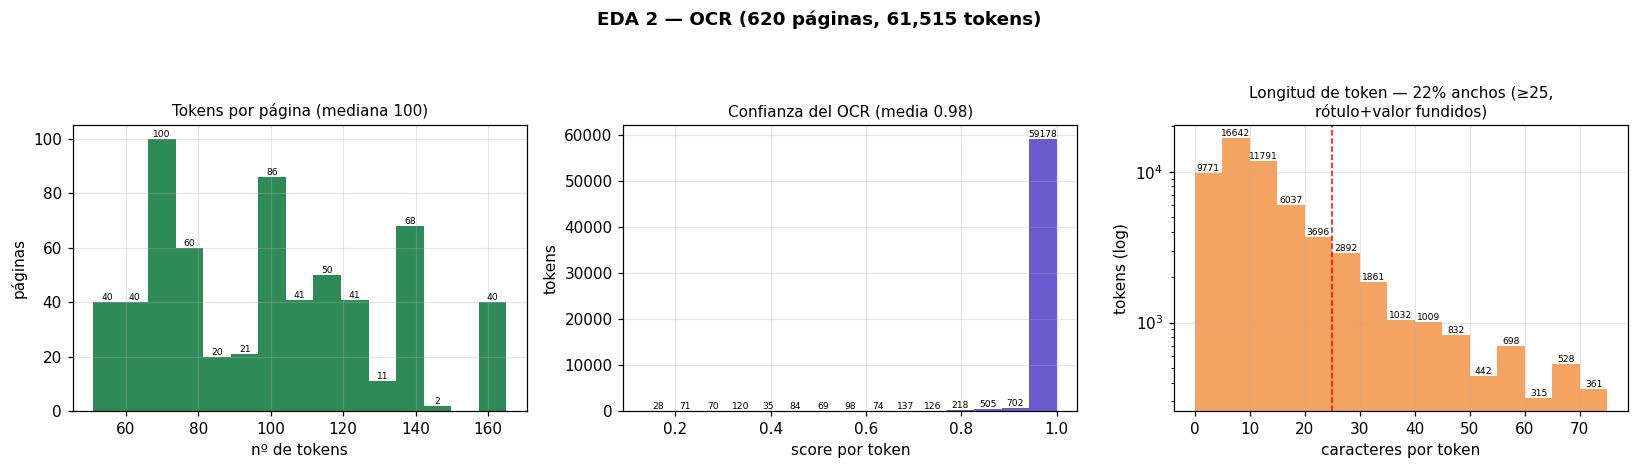

In [32]:
# ===== EDA 2 — OCR: tokens (gráficos; corre en el VPS) =====
assert os.path.isdir(OCR_DIR), f'Corre esta celda en el VPS: no existe {OCR_DIR}'
files = [f for f in glob.glob(f'{OCR_DIR}/*.json') if not os.path.basename(f).startswith('_')]
n_tok, scores, largos = [], [], []
for fp in files:
    d = json.load(open(fp, encoding='utf-8'))
    toks = d.get('tokens', [])
    n_tok.append(len(toks))
    for t in toks:
        scores.append(float(t.get('score', 0)))
        largos.append(len(t.get('text', '')))
anchos = sum(1 for l in largos if l >= 25)

fig, ax = plt.subplots(1, 3, figsize=(15, 4.3))
fig.suptitle(f'EDA 2 — OCR ({len(files)} páginas, {sum(n_tok):,} tokens)', fontweight='bold')

ax[0].hist(n_tok, bins=15, color='seagreen'); ax[0].set_title(f'Tokens por página (mediana {int(np.median(n_tok))})'); ax[0].set_xlabel('nº de tokens'); ax[0].set_ylabel('páginas')
ax[0].bar_label(ax[0].containers[0], labels=[int(v) if v else '' for v in ax[0].containers[0].datavalues], fontsize=6)
ax[1].hist(scores, bins=15, color='slateblue'); ax[1].set_title(f'Confianza del OCR (media {np.mean(scores):.2f})'); ax[1].set_xlabel('score por token'); ax[1].set_ylabel('tokens')
ax[1].bar_label(ax[1].containers[0], labels=[int(v) if v else '' for v in ax[1].containers[0].datavalues], fontsize=6)
ax[2].hist(largos, bins=range(0, 80, 5), color='sandybrown'); ax[2].axvline(25, color='red', ls='--', lw=1)
ax[2].set_yscale('log'); ax[2].set_xlabel('caracteres por token'); ax[2].set_ylabel('tokens (log)')
ax[2].set_title(f'Longitud de token — {anchos*100/max(len(largos),1):.0f}% anchos (≥25,\nrótulo+valor fundidos)')
ax[2].bar_label(ax[2].containers[0], labels=[int(v) if v else '' for v in ax[2].containers[0].datavalues], fontsize=6)

plt.tight_layout(rect=[0, 0, 1, 0.93]); plt.show()


## 5. Pre-etiquetado con Qwen 2.5 (supervisión débil)

Se utiliza un LLM local (Qwen 2.5) propone las etiquetas BIO, que luego se corrigen en Label Studio.

> **Decisión — Qwen local.** El pre-etiquetado usa un LLM local, la corrección humana en Label Studio queda como gold.

> **Entorno: `venv` (PaddleOCR) + Ollama — no `venv_kie`.**

In [6]:
# === PASO 2 (SE REALIZA 1 VEZ) — pre-etiquetado automatico con Qwen 2.5 ===
# Ya ejecutado: se corrio Qwen y luego se etiqueto/corrigio manualmente en Label Studio.
# Se deja COMENTADO por seguridad para no sobrescribir tu anotacion.
#
# run([sys.executable, 'pre_etiquetar_facturas.py',
#      '--ocr_dir', OCR_DIR,
#      '--salida_dir', f'{BASE}/facturas_etiquetadas',
#      '--ls_output', LS_JSON])
#
# --- Esencia del llamado a Qwen (referencia; vive dentro de pre_etiquetar_facturas.py) ---
# import requests
# payload = {'model': 'qwen2.5:7b', 'prompt': PROMPT.format(texto=texto_ocr[:5000]),
#            'stream': False, 'format': 'json', 'options': {'temperature': 0.0}}
# resp = requests.post('http://localhost:11434/api/generate', json=payload, timeout=90)
# campos = json.loads(resp.json()['response'])   # -> {NUMERO_FACTURA, NIT_EMISOR, ...}

## 6. Cobertura del pre-etiquetado

¿Cuánto acertó el pre-etiquetado de Qwen respecto al *gold*? La cobertura mide el acuerdo campo a campo, contando correctamente los campos ausentes en el gold, donde no había nada que capturar. Es un diagnóstico de la supervisión débil, no uno de los tres EDA de entrada.

> **Entorno.** La re-corrida de Qwen (celda siguiente) usa `venv` (PaddleOCR) + Ollama; el cálculo de cobertura corre en `venv_kie`.

> **Re-correr Qwen para el EDA (carpeta aparte) — Ollama + `requests`.** Vuelve a pre-etiquetar las ~620 páginas con los 8 campos (incluye `NUMERO_FACTURA`, `FECHA_GENERACION`, `IVA_TOTAL`, que faltaban en la corrida vieja) y escribe en `facturas_etiquetadas_eda/`. No toca `facturas_etiquetadas/`, `label_studio_import.json` ni `dataset_kie/` (el *gold* de los modelos queda intacto). Requiere Ollama con `qwen2.5:7b` activo; si el kernel `venv_kie` no tiene `requests`, instálalo (`pip install requests`) o corre este paso en una terminal con `source venv/bin/activate`.

In [9]:
# Re-corrida de Qwen para el EDA de cobertura (no afecta el gold: escribe en facturas_etiquetadas_eda).
# [CONSTRUCCION - se ejecuta una sola vez; requiere Ollama con qwen2.5:7b]
import subprocess, sys
LS_EDA = f'{BASE}/label_studio_import_eda.json'
FORZAR = 0  # 0 = reutiliza el pre-etiquetado del EDA; 1 = vuelve a correr Qwen sobre las facturas
if not salida_construccion(LS_EDA, FORZAR, que='el pre-etiquetado de Qwen para el EDA'):
    r = subprocess.run([sys.executable, 'pre_etiquetar_facturas.py',
                        '--ocr_dir', OCR_DIR,
                        '--salida_dir', ETIQ_EDA_DIR,        # NO sobrescribe el gold (facturas_etiquetadas)
                        '--ls_output', LS_EDA],
                       capture_output=True, text=True)
    print(r.stdout[-3000:])
    if r.returncode:
        print('STDERR:', r.stderr[-2000:])
    print('[exit', r.returncode, '] ->', ETIQ_EDA_DIR)

# --- Esencia del llamado a Qwen (referencia; vive dentro de pre_etiquetar_facturas.py) ---
# import requests
# payload = {'model': 'qwen2.5:7b', 'prompt': PROMPT.format(texto=texto_ocr[:5000]),
#            'stream': False, 'format': 'json', 'options': {'temperature': 0.0}}
# resp = requests.post('http://localhost:11434/api/generate', json=payload, timeout=90)
# campos = json.loads(resp.json()['response'])   # -> {NUMERO_FACTURA, NIT_EMISOR, ...}

[Salida ya generada -- fase de construccion. No se vuelve a ejecutar.]
Se reutiliza el resultado de el pre-etiquetado de Qwen para el EDA:
   - /home/jperezv/agente-documentos/label_studio_import_eda.json
Para volver a ejecutar este proceso, cambia FORZAR de 0 a 1 en esta celda.


Cobertura corregida del pre-etiquetado (acierto presencia/ausencia) · 600 facturas
pres_cap = presente y capturado | aus_vacio = ausente y dejado vacio (acierto) | pres_miss = presente no capturado | aus_extra = ausente pero capturado de mas


,presente_en_gold_%,pres_cap,aus_vacio,pres_miss,aus_extra,cobertura_%
VALOR_TOTAL,100.0,589,0,11,0,98.2
NIT_EMISOR,96.7,524,20,56,0,90.7
NUMERO_FACTURA,100.0,538,0,62,0,89.7
IVA_TOTAL,73.3,387,147,53,13,89.0
RAZON_SOCIAL_EMISOR,96.7,524,0,56,20,87.3
RAZON_SOCIAL_ADQUIRIENTE,100.0,479,0,121,0,79.8
FECHA_GENERACION,100.0,399,0,201,0,66.5
NIT_ADQUIRIENTE,100.0,363,0,237,0,60.5


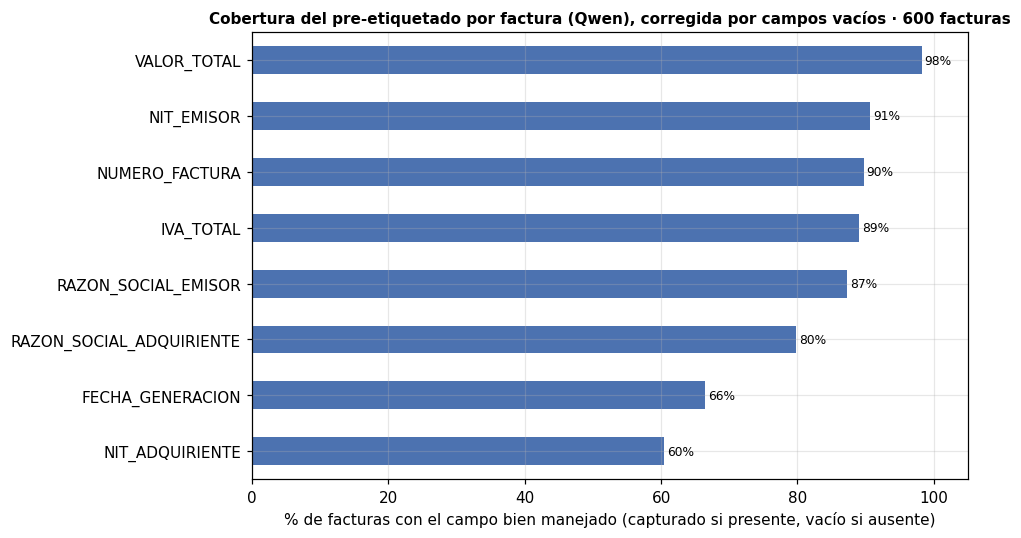

In [10]:
# ===== Cobertura del pre-etiquetado (Qwen), por campos vacios en el gold =====
# Mide si el pre-etiquetado (Paso 2) acierta la PRESENCIA/AUSENCIA de cada campo respecto al GOLD:
#   - presente en gold  Y  capturado por Qwen        -> acierto
#   - AUSENTE en gold    Y  NO capturado (vacio ok)   -> acierto  (no se penaliza el campo vacio)
#   - presente y no capturado / ausente y capturado   -> fallo
# Referencia del ESFUERZO de anotacion, NO una metrica del KIE. Corre en el VPS
# (necesita el pre-etiquetado facturas_etiquetadas/ + el gold label_studio_import.json).
from collections import defaultdict
ETIQ = f'{BASE}/facturas_etiquetadas'
assert os.path.isdir(ETIQ), f'Corre en el VPS: no existe {ETIQ} (salida del Paso 2).'
assert os.path.isfile(LS_JSON), f'Falta el gold {LS_JSON}.'
CAMPOS = ['NUMERO_FACTURA', 'FECHA_GENERACION', 'NIT_EMISOR', 'RAZON_SOCIAL_EMISOR',
          'NIT_ADQUIRIENTE', 'RAZON_SOCIAL_ADQUIRIENTE', 'VALOR_TOTAL', 'IVA_TOTAL']
SET_C = set(CAMPOS)

def _fid(name):
    base = os.path.splitext(os.path.basename(str(name)))[0]
    return re.sub(r'_p\d+$', '', base)

# (1) presencia en el GOLD por factura (label_studio_import.json)
gold = json.load(open(LS_JSON, encoding='utf-8'))
gold_present = defaultdict(set)
for task in gold:
    fid = _fid(task.get('data', {}).get('image', ''))
    for blk in (task.get('annotations') or task.get('predictions') or []):
        for r in blk.get('result', []):
            for lab in r.get('value', {}).get('rectanglelabels', []):
                if lab in SET_C:
                    gold_present[fid].add(lab)

# (2) campos capturados por Qwen por factura (pre-etiquetado)
qwen_cap = defaultdict(set)
for f in sorted(glob.glob(os.path.join(ETIQ, '*.json'))):
    d = json.load(open(f, encoding='utf-8'))
    fid = _fid(d.get('source') or f)
    labs = {t['label'].split('-', 1)[1] for t in d.get('tokens', []) if t.get('label', 'O') != 'O'}
    qwen_cap[fid] |= (labs & SET_C)

# (3) acierto por campo (presencia == captura) sobre las facturas del gold
facturas = sorted(gold_present)
N = len(facturas)
rows = {c: {'pres_cap': 0, 'aus_vacio': 0, 'pres_miss': 0, 'aus_extra': 0} for c in CAMPOS}
for fid in facturas:
    g = gold_present.get(fid, set()); q = qwen_cap.get(fid, set())
    for c in CAMPOS:
        pres, cap = (c in g), (c in q)
        if pres and cap:               rows[c]['pres_cap'] += 1
        elif (not pres) and (not cap):  rows[c]['aus_vacio'] += 1
        elif pres and not cap:          rows[c]['pres_miss'] += 1
        else:                           rows[c]['aus_extra'] += 1

det = pd.DataFrame(rows).T
det['acierto'] = det['pres_cap'] + det['aus_vacio']
det['cobertura_%'] = (det['acierto'] / N * 100).round(1)
# referencia: tasa de presencia del campo en el gold
det['presente_en_gold_%'] = pd.Series({c: len([f for f in facturas if c in gold_present[f]]) / N * 100 for c in CAMPOS}).round(1)
print(f'Cobertura corregida del pre-etiquetado (acierto presencia/ausencia) · {N} facturas')
print('pres_cap = presente y capturado | aus_vacio = ausente y dejado vacio (acierto) | '
      'pres_miss = presente no capturado | aus_extra = ausente pero capturado de mas')
display(det[['presente_en_gold_%', 'pres_cap', 'aus_vacio', 'pres_miss', 'aus_extra', 'cobertura_%']]
        .sort_values('cobertura_%', ascending=False))

cob = (det['cobertura_%']).sort_values()
fig, ax = plt.subplots(figsize=(9, 5))
cob.plot.barh(ax=ax, color='#4C72B0'); ax.set_xlim(0, 105)
ax.set_title(f'Cobertura del pre-etiquetado por factura (Qwen), corregida por campos vacíos · {N} facturas', fontweight='bold')
ax.set_xlabel('% de facturas con el campo bien manejado (capturado si presente, vacío si ausente)')
for cc in ax.containers:
    ax.bar_label(cc, fmt='%.0f%%', fontsize=8, padding=2)
plt.tight_layout(); plt.show()


## 7. Construir el dataset KIE · `preparar_dataset_kie.py`

Con los tokens del OCR y las cajas corregidas, se proyecta cada caja sobre sus tokens (solapamiento simétrico + rescate) para producir el dataset BIO, con cajas normalizadas a 0–1000 y el split por emisor.

> **Decisión — split por emisor (no aleatorio).** Se particiona por emisor (480/140) para medir la generalización a plantillas no vistas: ninguna página de un emisor cae a la vez en train y test. Cajas normalizadas a 0–1000 y matching caja - token simétrico + pasada de rescate.

> **Entorno: `venv_kie`**

In [11]:
# Paso 3: construir el dataset KIE (alinea tus cajas LS con los tokens OCR).
# [CONSTRUCCION - se ejecuta una sola vez]
FORZAR = 0  # 0 = reutiliza dataset_kie/ si ya existe; 1 = reconstruye el dataset
if not salida_construccion([f'{DATASET_DIR}/train.jsonl', f'{DATASET_DIR}/test.jsonl',
                            f'{DATASET_DIR}/labels.txt'], FORZAR, que='el dataset KIE'):
    run([sys.executable, 'preparar_dataset_kie.py',
         '--ocr_dir', OCR_DIR,
         '--ls_json', LS_JSON,
         '--salida_dir', DATASET_DIR,
         '--layout_regex', LAYOUT_REGEX,
         '--n_test_layouts', N_TEST_LAYOUTS])

[Salida ya generada -- fase de construccion. No se vuelve a ejecutar.]
Se reutiliza el resultado de el dataset KIE:
   - /home/jperezv/agente-documentos/dataset_kie/train.jsonl
   - /home/jperezv/agente-documentos/dataset_kie/test.jsonl
   - /home/jperezv/agente-documentos/dataset_kie/labels.txt
Para volver a ejecutar este proceso, cambia FORZAR de 0 a 1 en esta celda.


## 8. Inspección del dataset

Un vistazo al dataset resultante: conteos, distribución de etiquetas, avisos y un ejemplo real con sus tokens etiquetados.

> **Entorno: `venv_kie`**

In [12]:
# Resumen del dataset (split, distribucion de etiquetas, avisos)
resumen = Path(f'{DATASET_DIR}/_resumen_dataset.txt')
print(resumen.read_text(encoding='utf-8') if resumen.exists() else 'Aun no existe el resumen.')

Facturas con dataset: 620  (sin anotacion LS y omitidas: 0)
Layouts: 30  |  test layouts (6): ['layout_01', 'layout_04', 'layout_08', 'layout_09', 'layout_21', 'layout_24']
Split -> train: 480 facturas | test: 140 facturas
Etiquetas (17): ['O', 'B-FECHA_GENERACION', 'I-FECHA_GENERACION', 'B-IVA_TOTAL', 'I-IVA_TOTAL', 'B-NIT_ADQUIRIENTE', 'I-NIT_ADQUIRIENTE', 'B-NIT_EMISOR', 'I-NIT_EMISOR', 'B-NUMERO_FACTURA', 'I-NUMERO_FACTURA', 'B-RAZON_SOCIAL_ADQUIRIENTE', 'I-RAZON_SOCIAL_ADQUIRIENTE', 'B-RAZON_SOCIAL_EMISOR', 'I-RAZON_SOCIAL_EMISOR', 'B-VALOR_TOTAL', 'I-VALOR_TOTAL']

Distribucion de etiquetas (conteo de tokens):
  O                            56726
  B-FECHA_GENERACION           600
  I-FECHA_GENERACION           117
  B-IVA_TOTAL                  440
  I-IVA_TOTAL                  0
  B-NIT_ADQUIRIENTE            591
  I-NIT_ADQUIRIENTE            20
  B-NIT_EMISOR                 560
  I-NIT_EMISOR                 20
  B-NUMERO_FACTURA             600
  I-NUMERO_FACTURA          

In [13]:
# Un ejemplo del train: muestra solo los tokens con etiqueta (BIO)
train_path = f'{DATASET_DIR}/train.jsonl'
if os.path.exists(train_path):
    with open(train_path, encoding='utf-8') as f:
        ej = json.loads(f.readline())
    print('Factura:', ej['id'], '| layout:', ej['layout'], '| tokens:', len(ej['tokens']))
    print('Campos etiquetados:')
    for tok, lab in zip(ej['tokens'], ej['ner_tags']):
        if lab != 'O':
            print('  ' + lab.ljust(26) + ' ' + repr(tok))
else:
    print('Aun no existe train.jsonl')

Factura: layout_02_001 | layout: layout_02 | tokens: 76
Campos etiquetados:
  B-RAZON_SOCIAL_EMISOR      'EXPRESO BRASILIA S.A.'
  B-NIT_EMISOR               'NIT.890100531 -8'
  B-RAZON_SOCIAL_ADQUIRIENTE 'SEÑOR (ES): JUAN ALVAREZ SILVA PEREZ'
  B-NUMERO_FACTURA           'Nº 153826777'
  B-NIT_ADQUIRIENTE          'NIT: 1246565535-2'
  B-FECHA_GENERACION         'FECHA DE EMISIÓN: 08 / 08 / 2025 01:49'
  B-VALOR_TOTAL              '$90.000'


### 8.1 Dataset listo
Con `dataset_kie/` (`train.jsonl`, `test.jsonl`, `labels.txt`) generado y revisado, pasamos al entrenamiento de los dos modelos.

## 9. EDA 3 · Balance del dataset (train / prueba)

El tercer EDA comprueba que la partición por emisor (480 train / 140 prueba) sea representativa: proporción de cada campo en train vs prueba, facturas por emisor y composición O/entidad. Un test sesgado invalidaría las conclusiones.

> **Entorno: `venv_kie`**

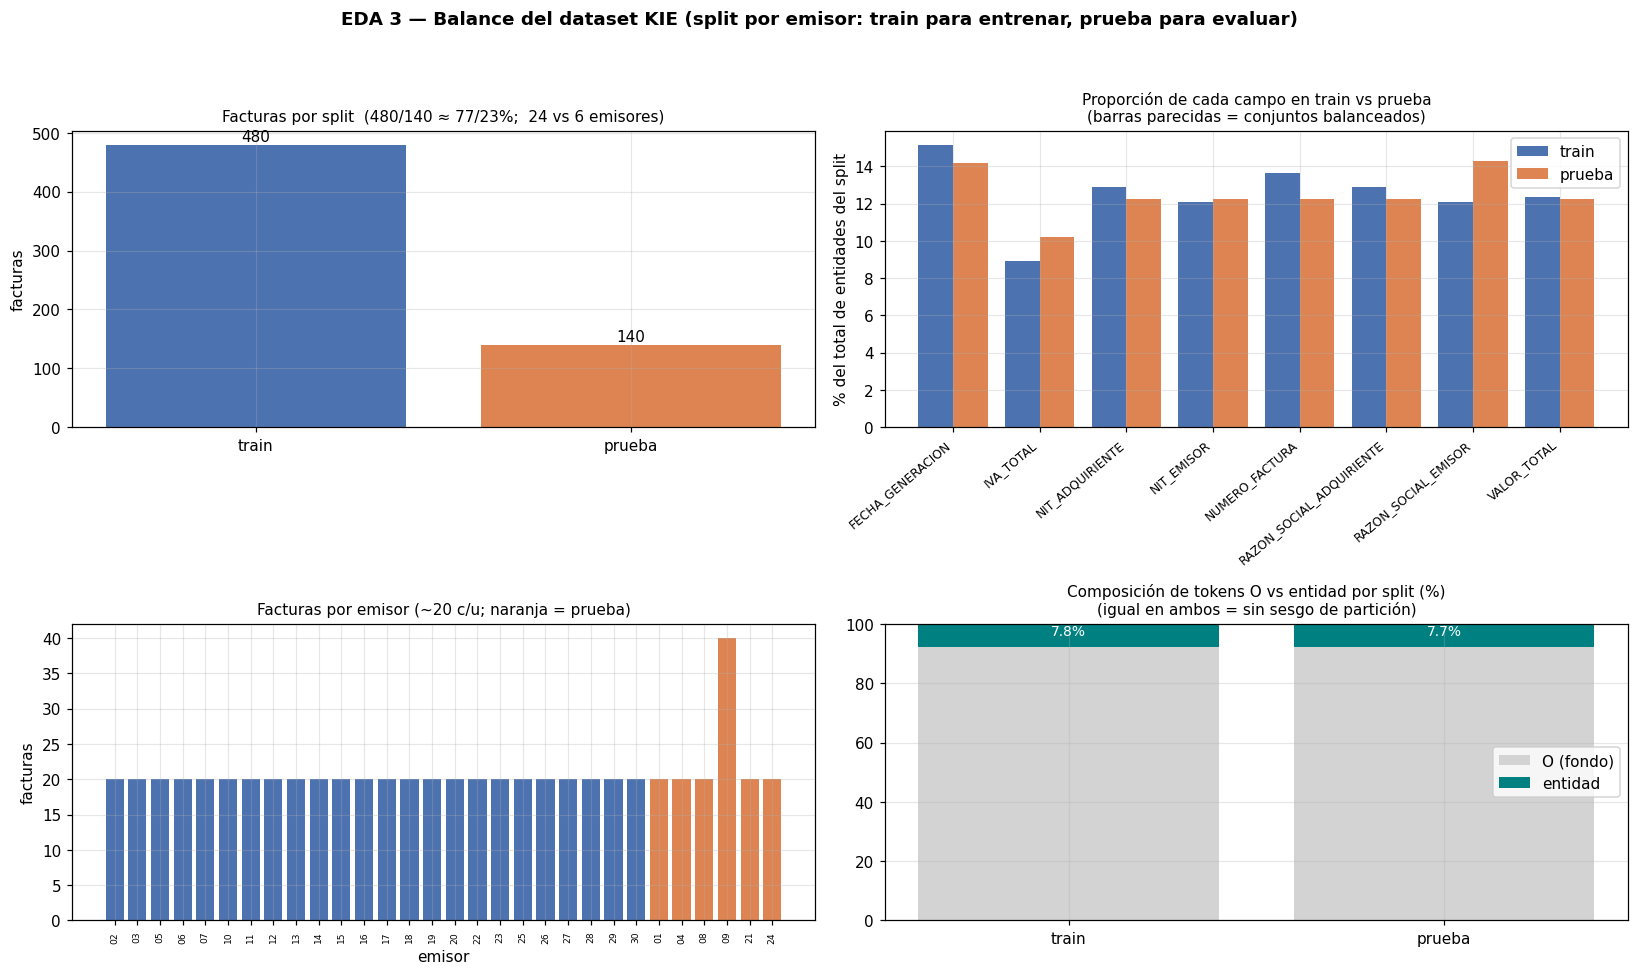

In [33]:
# ===== EDA 3 — Balance del dataset KIE: train / prueba / evaluación (gráficos; VPS) =====
# "Balanceado" aquí = el conjunto de PRUEBA es representativo del de ENTRENAMIENTO
# (mismas proporciones), de modo que entrenar/probar/evaluar es justo. El split es POR EMISOR.
assert os.path.isdir(DATASET_DIR), f'Corre esta celda en el VPS: no existe {DATASET_DIR}'

def _cargar(split):
    fp = f'{DATASET_DIR}/{split}.jsonl'
    return [json.loads(l) for l in open(fp, encoding='utf-8')] if os.path.exists(fp) else []

train, test = _cargar('train'), _cargar('test')

def _emisor(ej):
    if ej.get('layout'):
        return ej['layout']
    m = re.match(LAYOUT_REGEX, ej['id'])
    return m.group(1) if m else ej['id']

def _ent(ds):                                  # conteo por entidad (colapsa B-/I-)
    c = Counter()
    for ej in ds:
        for t in ej['ner_tags']:
            if t != 'O':
                c[t[2:]] += 1
    return c

def _share_O(ds):
    o = sum(1 for ej in ds for t in ej['ner_tags'] if t == 'O')
    tot = sum(len(ej['ner_tags']) for ej in ds) or 1
    return o / tot * 100

ct_tr, ct_te = _ent(train), _ent(test)
ents = sorted(set(ct_tr) | set(ct_te))
tot_tr, tot_te = sum(ct_tr.values()) or 1, sum(ct_te.values()) or 1
prop_tr = [ct_tr.get(e, 0) / tot_tr * 100 for e in ents]
prop_te = [ct_te.get(e, 0) / tot_te * 100 for e in ents]
fac_tr, fac_te = Counter(map(_emisor, train)), Counter(map(_emisor, test))
emis = sorted(set(fac_tr) | set(fac_te), key=lambda s: (s in fac_te, s))

fig, ax = plt.subplots(2, 2, figsize=(15, 9))
fig.suptitle('EDA 3 — Balance del dataset KIE (split por emisor: train para entrenar, prueba para evaluar)',
             fontweight='bold')

# (a) tamaño del split
b = ax[0, 0].bar(['train', 'prueba'], [len(train), len(test)], color=['#4C72B0', '#DD8452'])
ax[0, 0].bar_label(b)
ax[0, 0].set_ylabel('facturas')
ax[0, 0].set_title(f'Facturas por split  ({len(train)}/{len(test)} ≈ '
                   f'{len(train)/(len(train)+len(test))*100:.0f}/{len(test)/(len(train)+len(test))*100:.0f}%;  '
                   f'{len(fac_tr)} vs {len(fac_te)} emisores)')

# (b) proporción de cada campo dentro de su split: barras parecidas => test representativo
x, w = np.arange(len(ents)), 0.4
ax[0, 1].bar(x - w/2, prop_tr, w, label='train', color='#4C72B0')
ax[0, 1].bar(x + w/2, prop_te, w, label='prueba', color='#DD8452')
ax[0, 1].set_xticks(x); ax[0, 1].set_xticklabels(ents, rotation=40, ha='right', fontsize=8); ax[0, 1].legend()
ax[0, 1].set_ylabel('% del total de entidades del split')
ax[0, 1].set_title('Proporción de cada campo en train vs prueba\n(barras parecidas = conjuntos balanceados)')

# (c) facturas por emisor (~20 c/u; naranja = emisores de prueba)
col = ['#DD8452' if e in fac_te else '#4C72B0' for e in emis]
ax[1, 0].bar(range(len(emis)), [fac_tr.get(e, 0) + fac_te.get(e, 0) for e in emis], color=col)
ax[1, 0].set_title('Facturas por emisor (~20 c/u; naranja = prueba)')
ax[1, 0].set_xlabel('emisor'); ax[1, 0].set_ylabel('facturas')
ax[1, 0].set_xticks(range(len(emis))); ax[1, 0].set_xticklabels([e.replace('layout_', '') for e in emis], rotation=90, fontsize=6)

# (d) composición O vs entidad por split (mismo desbalance de fondo en ambos)
oT, oE = _share_O(train), _share_O(test)
ax[1, 1].bar(['train', 'prueba'], [oT, oE], color='lightgray', label='O (fondo)')
ax[1, 1].bar(['train', 'prueba'], [100 - oT, 100 - oE], bottom=[oT, oE], color='teal', label='entidad')
ax[1, 1].set_ylim(0, 100); ax[1, 1].legend(loc='center right')
ax[1, 1].set_title('Composición de tokens O vs entidad por split (%)\n(igual en ambos = sin sesgo de partición)')
for i, v in enumerate([100 - oT, 100 - oE]):
    ax[1, 1].text(i, 100 - v/2, f'{v:.1f}%', ha='center', color='white', fontsize=9)

plt.tight_layout(rect=[0, 0, 1, 0.95]); plt.show()


---
# PARTE II · Modelos, comparación y mejoras

Con el dataset listo empieza el modelado. Se entrenan y comparan dos arquitecturas de filosofías opuestas, LayoutLMv3** (multimodal, usa la imagen) y LiLT (solo texto+layout), se contrasta la diferencia con pruebas estadísticas, se analiza cómo fallan, se mide su generalización a emisores no vistos y, por último, se exploran tres mejoras.

## 10. Entrenamiento · LayoutLMv3 vs LiLT

Ambos modelos se afinan sobre el mismo dataset, con *early stopping* por F1 macro. se guarda el mejor de cada uno.

> **Decisión — LayoutLMv3 vs LiLT.** Dos filosofías opuestas (con/sin imagen), ambas abiertas, reproducibles, ajustables en una sola GPU L4 y con la misma cabeza BIO: comparación justa.

> **Entorno: `venv_kie`**

In [15]:
# === Dependencias (ejecutar UNA vez; descomenta) ===
# Idealmente en un venv aparte para no romper el del pipeline (PaddleOCR).
# torch con CUDA: instalar segun tu CUDA -> https://pytorch.org  (NO el torch CPU)
# !pip install -q 'transformers>=4.41' 'accelerate>=0.26' datasets seqeval evaluate pillow sentencepiece
# Verifica que torch vea la GPU L4 antes de entrenar:
import torch
print('torch', torch.__version__, '| CUDA disponible:', torch.cuda.is_available(),
      '|', (torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'sin GPU'))


torch 2.6.0+cu124 | CUDA disponible: True | NVIDIA L4


In [16]:
# === Entrenamiento KIE: LayoutLMv3 vs LiLT (token classification) ===
import inspect, os, json
import numpy as np
from transformers import (AutoProcessor, AutoModelForTokenClassification,
                          LayoutXLMTokenizerFast, TrainingArguments, Trainer,
                          EarlyStoppingCallback)
from datasets import load_dataset
from PIL import Image
import evaluate

# --- Config de los dos modelos ---
MODELOS = {
    'layoutlmv3': {'ckpt': 'microsoft/layoutlmv3-base', 'usa_imagen': True},
    'lilt':       {'ckpt': 'SCUT-DLVCLab/lilt-infoxlm-base', 'usa_imagen': False,
                   'tok_ckpt': 'microsoft/layoutxlm-base'},
}
# EPOCHS es el tope; el early stopping suele cortar antes. BATCH=2 cabe en la L4.
MAX_LEN, EPOCHS, LR, BATCH, PATIENCE = 512, 30, 5e-5, 2, 5

# --- Etiquetas y dataset ---
LABELS = Path(f'{DATASET_DIR}/labels.txt').read_text(encoding='utf-8').split()
id2label = {i: l for i, l in enumerate(LABELS)}
label2id = {l: i for i, l in enumerate(LABELS)}
ds = load_dataset('json', data_files={'train': f'{DATASET_DIR}/train.jsonl',
                                       'test':  f'{DATASET_DIR}/test.jsonl'})
print('Etiquetas:', len(LABELS), '| dataset:', ds)

seqeval = evaluate.load('seqeval')

def compute_metrics(p):
    logits, labels = p
    preds = np.argmax(logits, axis=2)
    true_p = [[id2label[a] for a, l in zip(P, L) if l != -100] for P, L in zip(preds, labels)]
    true_l = [[id2label[l] for a, l in zip(P, L) if l != -100] for P, L in zip(preds, labels)]
    r = seqeval.compute(predictions=true_p, references=true_l, zero_division=0)
    out = {'f1_macro': r['overall_f1'], 'precision': r['overall_precision'], 'recall': r['overall_recall']}
    for k, v in r.items():
        if isinstance(v, dict):
            out['f1_' + k] = v['f1']   # F1 por entidad (sin prefijo BIO)
    return out

def _prep_v3(proc):
    def fn(ex):
        imgs = [Image.open(p).convert('RGB') for p in ex['image_path']]
        wl = [[label2id[l] for l in tags] for tags in ex['ner_tags']]
        return proc(imgs, ex['tokens'], boxes=ex['bboxes'], word_labels=wl,
                    truncation=True, padding='max_length', max_length=MAX_LEN)
    return fn

def _prep_lilt(tok):
    def fn(ex):
        wl = [[label2id[l] for l in tags] for tags in ex['ner_tags']]
        return tok(ex['tokens'], boxes=ex['bboxes'], word_labels=wl,
                   truncation=True, padding='max_length', max_length=MAX_LEN)
    return fn

# Compatibilidad entre versiones de transformers:
#  - eval_strategy (>=4.41) vs evaluation_strategy (anterior)
#  - Trainer(processing_class=...) (>=4.46) vs Trainer(tokenizer=...) (anterior, ya eliminado en v5)
_ta_params = inspect.signature(TrainingArguments.__init__).parameters
_EVAL_KEY = 'eval_strategy' if 'eval_strategy' in _ta_params else 'evaluation_strategy'
_tr_params = inspect.signature(Trainer.__init__).parameters
_PROC_KEY = 'processing_class' if 'processing_class' in _tr_params else 'tokenizer'

def entrenar_modelo(nombre, forzar=False):
    """Entrena y guarda en kie_<nombre>/best. Si ese modelo YA existe y forzar=False,
    NO re-entrena: lo carga y solo lo evalua (para rellenar 'resultados'). Usa forzar=True
    para re-entrenar desde cero. Siempre guarda las metricas en kie_<nombre>/metrics.json
    para que la comparativa funcione aunque se reinicie el kernel."""
    cfg = MODELOS[nombre]
    best_dir = f'{BASE}/kie_{nombre}/best'
    ya_entrenado = os.path.exists(f'{best_dir}/config.json')
    reutilizar = ya_entrenado and not forzar
    print('\n=====', ('Reutilizando' if reutilizar else 'Entrenando'), nombre,
          '(' + (best_dir if reutilizar else cfg['ckpt']) + ') =====')

    # processor/tokenizer: del best si reutilizamos, del checkpoint base si entrenamos
    src = best_dir if reutilizar else (cfg['ckpt'] if cfg['usa_imagen'] else cfg['tok_ckpt'])
    if cfg['usa_imagen']:
        tok_trainer = AutoProcessor.from_pretrained(src, apply_ocr=False)
        enc = ds.map(_prep_v3(tok_trainer), batched=True, remove_columns=ds['train'].column_names)
    else:
        tok_trainer = LayoutXLMTokenizerFast.from_pretrained(src)
        enc = ds.map(_prep_lilt(tok_trainer), batched=True, remove_columns=ds['train'].column_names)
    enc.set_format('torch')

    if reutilizar:
        model = AutoModelForTokenClassification.from_pretrained(best_dir)
    else:
        model = AutoModelForTokenClassification.from_pretrained(
            cfg['ckpt'], num_labels=len(LABELS), id2label=id2label, label2id=label2id)

    # eval Y save por epoca + seleccion del mejor modelo por F1 macro (no la ultima epoca)
    ta_kwargs = dict(
        output_dir=f'{BASE}/kie_' + nombre,
        per_device_train_batch_size=BATCH, per_device_eval_batch_size=BATCH,
        learning_rate=LR, num_train_epochs=EPOCHS,
        warmup_ratio=0.1, weight_decay=0.01,
        save_strategy='epoch', save_total_limit=1,
        load_best_model_at_end=True, metric_for_best_model='f1_macro', greater_is_better=True,
        logging_steps=20, report_to='none', seed=42)
    ta_kwargs[_EVAL_KEY] = 'epoch'
    args = TrainingArguments(**ta_kwargs)

    tr_kwargs = dict(model=model, args=args, train_dataset=enc['train'],
                     eval_dataset=enc['test'], compute_metrics=compute_metrics,
                     callbacks=[EarlyStoppingCallback(early_stopping_patience=PATIENCE)])
    tr_kwargs[_PROC_KEY] = tok_trainer      # processing_class (nuevo) o tokenizer (viejo)
    trainer = Trainer(**tr_kwargs)

    if reutilizar:
        m = trainer.evaluate()              # solo evalua el modelo ya entrenado
        print('  (no re-entrenado; pasa forzar=True para re-entrenar)')
    else:
        trainer.train()
        m = trainer.evaluate()              # con el MEJOR modelo (load_best_model_at_end)
        trainer.save_model(best_dir)        # guarda el ganador + procesador/tokenizer
        tok_trainer.save_pretrained(best_dir)

    # Persistir metricas para que la comparativa (#19) funcione sin depender de la memoria
    with open(f'{BASE}/kie_{nombre}/metrics.json', 'w', encoding='utf-8') as f:
        json.dump(m, f)
    print(nombre, '-> F1 macro:', round(m.get('eval_f1_macro', 0), 4), '|', best_dir)
    return m

print("Listo. entrenar_modelo('layoutlmv3') / ('lilt') reutiliza kie_*/best si ya existe; forzar=True re-entrena.")


Etiquetas: 17 | dataset: DatasetDict({
    train: Dataset({
        features: ['id', 'image_path', 'layout', 'tokens', 'bboxes', 'ner_tags'],
        num_rows: 480
    })
    test: Dataset({
        features: ['id', 'image_path', 'layout', 'tokens', 'bboxes', 'ner_tags'],
        num_rows: 140
    })
})
Listo. entrenar_modelo('layoutlmv3') / ('lilt') reutiliza kie_*/best si ya existe; forzar=True re-entrena.


In [17]:
# Entrenar LayoutLMv3.
# [CONSTRUCCION - se ejecuta una sola vez; entrena en GPU]
FORZAR = 0  # 0 = reutiliza kie_layoutlmv3/best si existe; 1 = re-entrena desde cero
resultados = globals().get('resultados', {})
if not salida_construccion(f'{BASE}/kie_layoutlmv3/best/config.json', FORZAR,
                           que='el modelo LayoutLMv3 base'):
    resultados['layoutlmv3'] = entrenar_modelo('layoutlmv3', forzar=bool(FORZAR))

[Salida ya generada -- fase de construccion. No se vuelve a ejecutar.]
Se reutiliza el resultado de el modelo LayoutLMv3 base:
   - /home/jperezv/agente-documentos/kie_layoutlmv3/best/config.json
Para volver a ejecutar este proceso, cambia FORZAR de 0 a 1 en esta celda.


In [18]:
# Entrenar LiLT.
# [CONSTRUCCION - se ejecuta una sola vez; entrena en GPU]
FORZAR = 0  # 0 = reutiliza kie_lilt/best si existe; 1 = re-entrena desde cero
resultados = globals().get('resultados', {})
if not salida_construccion(f'{BASE}/kie_lilt/best/config.json', FORZAR,
                           que='el modelo LiLT base'):
    resultados['lilt'] = entrenar_modelo('lilt', forzar=bool(FORZAR))

[Salida ya generada -- fase de construccion. No se vuelve a ejecutar.]
Se reutiliza el resultado de el modelo LiLT base:
   - /home/jperezv/agente-documentos/kie_lilt/best/config.json
Para volver a ejecutar este proceso, cambia FORZAR de 0 a 1 en esta celda.


In [19]:
# === Comparativa LayoutLMv3 vs LiLT ===
import json, os
resultados = globals().get('resultados', {})
# Fallback: si un modelo no esta en memoria, leer sus metricas de kie_<modelo>/metrics.json
# (lo escribe entrenar_modelo). Asi la comparativa funciona aunque se reinicie el kernel,
# sin necesidad de re-correr #4/#5/#6 (solo requiere la config #1 y los metrics.json en disco).
for nombre in ['layoutlmv3', 'lilt']:
    if nombre not in resultados:
        mp = f'{BASE}/kie_{nombre}/metrics.json'
        if os.path.exists(mp):
            resultados[nombre] = json.load(open(mp, encoding='utf-8'))
            print(f'(leido de disco: {mp})')

if resultados:
    print('Modelo        F1_macro  Precision  Recall')
    for nombre, m in resultados.items():
        print(f"{nombre:<12}  {m.get('eval_f1_macro',0):.4f}    {m.get('eval_precision',0):.4f}     {m.get('eval_recall',0):.4f}")
    # F1 por entidad
    ents = sorted({k[len('eval_f1_'):] for m in resultados.values() for k in m
                   if k.startswith('eval_f1_') and k != 'eval_f1_macro'})
    print('\nF1 por entidad:')
    for e in ents:
        linea = '  ' + e.ljust(26)
        for nombre, m in resultados.items():
            linea += f"  {nombre}={m.get('eval_f1_'+e,0):.3f}"
        print(linea)
    ganador = max(resultados, key=lambda n: resultados[n].get('eval_f1_macro', 0))
    print('\nModelo con mejor F1 macro (split por layout):', ganador)
else:
    print('Aun no hay resultados. Corre #5/#6 (entrenar_modelo) o asegura que existan kie_*/metrics.json.')


(leido de disco: /home/jperezv/agente-documentos/kie_layoutlmv3/metrics.json)
(leido de disco: /home/jperezv/agente-documentos/kie_lilt/metrics.json)
Modelo        F1_macro  Precision  Recall
layoutlmv3    0.6709    0.6220     0.7281
lilt          0.7263    0.6859     0.7718

F1 por entidad:
  FECHA_GENERACION            layoutlmv3=0.641  lilt=0.749
  IVA_TOTAL                   layoutlmv3=0.400  lilt=0.783
  NIT_ADQUIRIENTE             layoutlmv3=0.549  lilt=0.643
  NIT_EMISOR                  layoutlmv3=0.923  lilt=0.876
  NUMERO_FACTURA              layoutlmv3=0.745  lilt=0.758
  RAZON_SOCIAL_ADQUIRIENTE    layoutlmv3=0.599  lilt=0.654
  RAZON_SOCIAL_EMISOR         layoutlmv3=0.650  lilt=0.530
  VALOR_TOTAL                 layoutlmv3=0.694  lilt=0.740

Modelo con mejor F1 macro (split por layout): lilt


## 11. Comparativa y validación estadística (modelos base)

¿La ventaja de un modelo es real o azar del test? Se compara el F1 con bootstrap (intervalos de confianza) y aleatorización aproximada, pruebas apropiadas para una diferencia de F1.

> **Entorno: `venv_kie`**

In [20]:
# Validacion estadistica: LayoutLMv3 vs LiLT (bootstrap CIs + aleatorizacion aproximada)
# Carga los modelos guardados (kie_*/best), predice sobre el test y reporta significancia.
# Requiere GPU + venv_kie (mismo entorno del entrenamiento).
run([sys.executable, 'validar_kie_estadistico.py',
     '--dataset_dir', DATASET_DIR,
     '--layoutlmv3', f'{BASE}/kie_layoutlmv3/best',
     '--lilt',       f'{BASE}/kie_lilt/best',
     '--n_boot', 2000])


$ /home/jperezv/agente-documentos/venv_kie/bin/python validar_kie_estadistico.py --dataset_dir /home/jperezv/agente-documentos/dataset_kie --layoutlmv3 /home/jperezv/agente-documentos/kie_layoutlmv3/best --lilt /home/jperezv/agente-documentos/kie_lilt/best --n_boot 2000
device: cuda
documentos de test: 140

Prediciendo con layoutlmv3 (/home/jperezv/agente-documentos/kie_layoutlmv3/best) ...


Loading weights: 100%|██████████| 216/216 [00:00<00:00, 958.44it/s] 



Prediciendo con lilt (/home/jperezv/agente-documentos/kie_lilt/best) ...


Loading weights: 100%|██████████| 400/400 [00:00<00:00, 1192.62it/s]



===== F1 overall (micro) =====
  layoutlmv3   F1 = 0.6439
  lilt         F1 = 0.7090
  diferencia (lilt - layoutlmv3) = +0.0651

===== Bootstrap 95% CI (2000 resamples, por documento) =====
  layoutlmv3   F1 = 0.6439  IC95% [0.6090, 0.6775]
  lilt         F1 = 0.7090  IC95% [0.6750, 0.7420]
  diferencia (lilt - layoutlmv3) = +0.0651  IC95% [+0.0464, +0.0828] -> SIGNIFICATIVA (IC no cruza 0)

===== McNemar pareado (entidades gold) =====
  entidades gold totales: 940
  ambos aciertan: 589 | ambos fallan: 169
  solo LayoutLMv3 acierta (b): 51 | solo LiLT acierta (c): 131
  McNemar p-valor exacto (bilateral) = 2.651e-09
  -> diferencia significativa (p<0.05)
[exit code: 0]


0

## 12. Análisis de errores (modelos base): confusión y entropía

La matriz de confusión revela si el error es no-detección (hacia `O`) o confusión entre campos, y la entropía mide la confianza y calibración de cada modelo.

> **Entorno: `venv_kie`**


===================  layoutlmv3  ===================


Loading weights:   0%|          | 0/216 [00:00<?, ?it/s]

Matriz de confusion (conteo de tokens):


,P:O,P:FECHA_GENERACION,P:IVA_TOTAL,P:NIT_ADQUIRIENTE,P:NIT_EMISOR,P:NUMERO_FACTURA,P:RAZON_SOCIAL_ADQUIRIENTE,P:RAZON_SOCIAL_EMISOR,P:VALOR_TOTAL
V:O,11443,22,20,78,20,62,88,26,33
V:FECHA_GENERACION,63,76,0,0,0,0,0,0,0
V:IVA_TOTAL,80,0,20,0,0,0,0,0,0
V:NIT_ADQUIRIENTE,25,0,0,75,0,20,0,0,0
V:NIT_EMISOR,0,0,0,0,120,0,0,0,0
V:NUMERO_FACTURA,0,0,0,0,0,120,0,0,0
V:RAZON_SOCIAL_ADQUIRIENTE,31,0,0,0,0,0,89,0,0
V:RAZON_SOCIAL_EMISOR,40,0,0,0,0,0,0,100,0
V:VALOR_TOTAL,60,0,0,0,0,0,0,0,60


Normalizada por fila (la diagonal = recall por clase):


,P:O,P:FECHA_GENERACION,P:IVA_TOTAL,P:NIT_ADQUIRIENTE,P:NIT_EMISOR,P:NUMERO_FACTURA,P:RAZON_SOCIAL_ADQUIRIENTE,P:RAZON_SOCIAL_EMISOR,P:VALOR_TOTAL
V:O,0.970,0.002,0.002,0.007,0.002,0.005,0.007,0.002,0.003
V:FECHA_GENERACION,0.453,0.547,0.000,0.000,0.000,0.000,0.000,0.000,0.000
V:IVA_TOTAL,0.800,0.000,0.200,0.000,0.000,0.000,0.000,0.000,0.000
V:NIT_ADQUIRIENTE,0.208,0.000,0.000,0.625,0.000,0.167,0.000,0.000,0.000
V:NIT_EMISOR,0.000,0.000,0.000,0.000,1.000,0.000,0.000,0.000,0.000
V:NUMERO_FACTURA,0.000,0.000,0.000,0.000,0.000,1.000,0.000,0.000,0.000
V:RAZON_SOCIAL_ADQUIRIENTE,0.258,0.000,0.000,0.000,0.000,0.000,0.742,0.000,0.000
V:RAZON_SOCIAL_EMISOR,0.286,0.000,0.000,0.000,0.000,0.000,0.000,0.714,0.000
V:VALOR_TOTAL,0.500,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.500


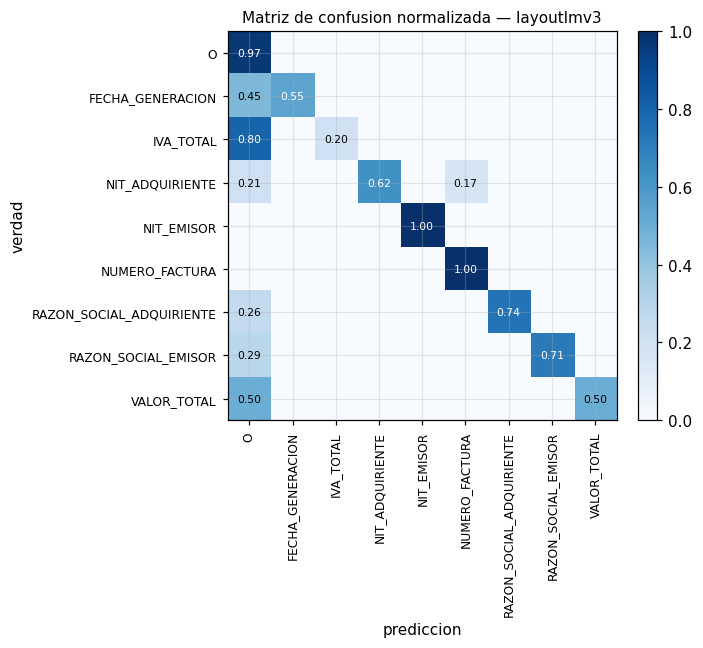

Entropia media: todos los tokens = 0.033 bits | solo tokens-entidad = 0.109 bits (maximo teorico = 4.087 bits)

===================  lilt  ===================


Loading weights:   0%|          | 0/400 [00:00<?, ?it/s]

Matriz de confusion (conteo de tokens):


,P:O,P:FECHA_GENERACION,P:IVA_TOTAL,P:NIT_ADQUIRIENTE,P:NIT_EMISOR,P:NUMERO_FACTURA,P:RAZON_SOCIAL_ADQUIRIENTE,P:RAZON_SOCIAL_EMISOR,P:VALOR_TOTAL
V:O,11493,33,17,82,40,20,48,57,2
V:FECHA_GENERACION,36,103,0,0,0,0,0,0,0
V:IVA_TOTAL,22,0,78,0,0,0,0,0,0
V:NIT_ADQUIRIENTE,20,0,0,98,0,2,0,0,0
V:NIT_EMISOR,0,0,0,0,118,0,0,2,0
V:NUMERO_FACTURA,20,0,0,0,0,100,0,0,0
V:RAZON_SOCIAL_ADQUIRIENTE,36,0,0,0,0,0,81,3,0
V:RAZON_SOCIAL_EMISOR,20,0,0,0,0,0,0,120,0
V:VALOR_TOTAL,52,0,6,0,0,0,0,0,62


Normalizada por fila (la diagonal = recall por clase):


,P:O,P:FECHA_GENERACION,P:IVA_TOTAL,P:NIT_ADQUIRIENTE,P:NIT_EMISOR,P:NUMERO_FACTURA,P:RAZON_SOCIAL_ADQUIRIENTE,P:RAZON_SOCIAL_EMISOR,P:VALOR_TOTAL
V:O,0.975,0.003,0.001,0.007,0.003,0.002,0.004,0.005,0.000
V:FECHA_GENERACION,0.259,0.741,0.000,0.000,0.000,0.000,0.000,0.000,0.000
V:IVA_TOTAL,0.220,0.000,0.780,0.000,0.000,0.000,0.000,0.000,0.000
V:NIT_ADQUIRIENTE,0.167,0.000,0.000,0.817,0.000,0.017,0.000,0.000,0.000
V:NIT_EMISOR,0.000,0.000,0.000,0.000,0.983,0.000,0.000,0.017,0.000
V:NUMERO_FACTURA,0.167,0.000,0.000,0.000,0.000,0.833,0.000,0.000,0.000
V:RAZON_SOCIAL_ADQUIRIENTE,0.300,0.000,0.000,0.000,0.000,0.000,0.675,0.025,0.000
V:RAZON_SOCIAL_EMISOR,0.143,0.000,0.000,0.000,0.000,0.000,0.000,0.857,0.000
V:VALOR_TOTAL,0.433,0.000,0.050,0.000,0.000,0.000,0.000,0.000,0.517


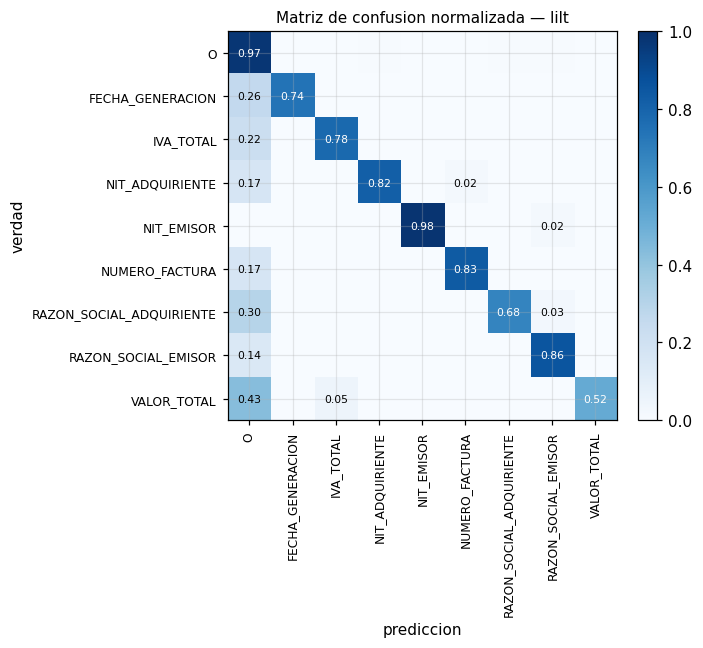

Entropia media: todos los tokens = 0.011 bits | solo tokens-entidad = 0.044 bits (maximo teorico = 4.087 bits)

=====  Entropia predictiva media por modelo (menor = mas confiado)  =====
modelo           todos   entidad
layoutlmv3       0.033     0.109
lilt             0.011     0.044


In [21]:
# === Matriz de confusion (nivel entidad) + entropia predictiva media por modelo ===
import json, numpy as np, torch
import pandas as pd
from PIL import Image
from IPython.display import display
from validar_kie_estadistico import cargar_modelo, MAX_LEN

try:
    import matplotlib.pyplot as plt
    HAS_MPL = True
except ImportError:
    HAS_MPL = False
    print('(Opcional: pip install matplotlib para los heatmaps; las tablas se muestran igual)')

device = 'cuda' if torch.cuda.is_available() else 'cpu'
test = [json.loads(l) for l in open(f'{DATASET_DIR}/test.jsonl', encoding='utf-8')]
LABELS = open(f'{DATASET_DIR}/labels.txt', encoding='utf-8').read().split()
ENTS = ['O'] + sorted({l[2:] for l in LABELS if l != 'O'})   # clases a nivel entidad
ci = {e: i for i, e in enumerate(ENTS)}
grp = lambda l: 'O' if l == 'O' else l[2:]                    # colapsa B-/I- -> entidad

@torch.no_grad()
def pred_rico(ej, proc, model, id2label, usa_imagen):
    """Predice etiquetas por palabra y la entropia (bits) de cada token (primera subpalabra)."""
    words, boxes = ej['tokens'], ej['bboxes']
    if usa_imagen:
        img = Image.open(ej['image_path']).convert('RGB')
        enc = proc(img, words, boxes=boxes, return_tensors='pt',
                   truncation=True, padding='max_length', max_length=MAX_LEN)
    else:
        enc = proc(words, boxes=boxes, return_tensors='pt',
                   truncation=True, padding='max_length', max_length=MAX_LEN)
    word_ids = enc.word_ids(0)
    inputs = {k: v.to(device) for k, v in enc.items()}
    logits = model(**inputs).logits[0]
    probs = torch.softmax(logits, -1)
    ent = -(probs * torch.log2(probs.clamp_min(1e-12))).sum(-1)   # entropia de Shannon (bits)
    preds = logits.argmax(-1).tolist()
    wp, we = {}, {}
    for idx, wid in enumerate(word_ids):
        if wid is None or wid in wp:
            continue
        wp[wid] = id2label[preds[idx]]
        we[wid] = float(ent[idx])
    pred_labels = [wp.get(i, 'O') for i in range(len(words))]
    ent_words = [we.get(i, float('nan')) for i in range(len(words))]
    return pred_labels, ent_words

resumen_entropia = {}
for nombre, mdir in [('layoutlmv3', f'{BASE}/kie_layoutlmv3/best'),
                     ('lilt',       f'{BASE}/kie_lilt/best')]:
    print(f'\n===================  {nombre}  ===================')
    proc, model, id2label, usa_imagen = cargar_modelo(mdir, device)
    yt, yp, ent_all, ent_entidad = [], [], [], []
    for ej in test:
        pl, ew = pred_rico(ej, proc, model, id2label, usa_imagen)
        for t, p, e in zip(ej['ner_tags'], pl, ew):
            yt.append(grp(t)); yp.append(grp(p)); ent_all.append(e)
            if t != 'O':
                ent_entidad.append(e)
    del model
    if device == 'cuda':
        torch.cuda.empty_cache()

    # --- Matriz de confusion (filas = verdad, columnas = prediccion) ---
    M = np.zeros((len(ENTS), len(ENTS)), int)
    for t, p in zip(yt, yp):
        M[ci[t], ci[p]] += 1
    df = pd.DataFrame(M, index=[f'V:{e}' for e in ENTS], columns=[f'P:{e}' for e in ENTS])
    dfn = df.div(df.sum(axis=1).replace(0, 1), axis=0)   # normalizada por fila (recall en diagonal)
    print('Matriz de confusion (conteo de tokens):'); display(df)
    print('Normalizada por fila (la diagonal = recall por clase):'); display(dfn.round(3))

    if HAS_MPL:
        fig, ax = plt.subplots(figsize=(7, 6))
        im = ax.imshow(dfn.values, vmin=0, vmax=1, cmap='Blues')
        ax.set_xticks(range(len(ENTS))); ax.set_xticklabels(ENTS, rotation=90, fontsize=8)
        ax.set_yticks(range(len(ENTS))); ax.set_yticklabels(ENTS, fontsize=8)
        ax.set_xlabel('prediccion'); ax.set_ylabel('verdad')
        ax.set_title(f'Matriz de confusion normalizada — {nombre}')
        for i in range(len(ENTS)):
            for j in range(len(ENTS)):
                v = dfn.values[i, j]
                if v > 0.01:
                    ax.text(j, i, f'{v:.2f}', ha='center', va='center', fontsize=7,
                            color='white' if v > 0.5 else 'black')
        fig.colorbar(im, fraction=0.046, pad=0.04); plt.tight_layout(); plt.show()

    # --- Entropia predictiva media (bits) ---
    h_all = float(np.nanmean(ent_all)); h_ent = float(np.nanmean(ent_entidad))
    resumen_entropia[nombre] = (h_all, h_ent)
    print(f'Entropia media: todos los tokens = {h_all:.3f} bits | solo tokens-entidad = {h_ent:.3f} bits '
          f'(maximo teorico = {np.log2(len(LABELS)):.3f} bits)')

print('\n=====  Entropia predictiva media por modelo (menor = mas confiado)  =====')
print(f"{'modelo':<12}{'todos':>10}{'entidad':>10}")
for n, (a, e) in resumen_entropia.items():
    print(f'{n:<12}{a:>10.3f}{e:>10.3f}')


## 13. Mejora A · *Focal loss*

El análisis de errores mostró que el problema es la no-detección de las clases raras. La *focal loss* ataca justo eso: resta peso a los abundantes tokens de fondo y concentra el aprendizaje en las entidades difíciles.

> **Decisión — focal pura.** La corrida final usa *focal loss* sin pesos por clase (alfa desactivado): el propio factor de modulación bastó para reorientar el aprendizaje hacia las clases raras.

> **Entorno: `venv_kie`**

In [22]:
# Re-entrenamiento con FOCAL LOSS (sube el recall de las clases raras).
# Requiere haber corrido antes la seccion de entrenamiento (define ds, LABELS, _prep_*, MODELOS, ...).
# Re-entrena en GPU y guarda en kie_<modelo>_focal/best, sin tocar los modelos base.
# [CONSTRUCCION - se ejecuta una sola vez; entrena en GPU]
import os, torch, torch.nn.functional as F, json, math, collections
from transformers import (AutoProcessor, AutoModelForTokenClassification,
                          LayoutXLMTokenizerFast, TrainingArguments, Trainer, EarlyStoppingCallback)

GAMMA = 1.0   # foco en ejemplos dificiles (gamma=0 -> CE normal)

class FocalTrainer(Trainer):
    def __init__(self, *a, gamma=2.0, alpha=None, **k):
        super().__init__(*a, **k)
        self.gamma = gamma
        self.alpha = alpha.to(self.args.device) if alpha is not None else None
    def compute_loss(self, model, inputs, return_outputs=False, **kw):
        labels = inputs.pop("labels")
        out = model(**inputs)
        C = out.logits.size(-1)
        lg, lb = out.logits.view(-1, C), labels.view(-1)
        m = lb != -100
        lg, lb = lg[m], lb[m]
        ce = F.cross_entropy(lg, lb, weight=self.alpha, reduction='none')
        pt = torch.exp(-ce)
        loss = ((1 - pt) ** self.gamma * ce).mean()
        return (loss, out) if return_outputs else loss

def _alpha_inv_freq():
    cnt = collections.Counter()
    for ex in ds['train']:
        for t in ex['ner_tags']:
            cnt[t] += 1
    w = torch.tensor([1.0 / math.sqrt(cnt.get(l, 1)) for l in LABELS], dtype=torch.float)
    return w / w.mean()

def entrenar_focal(nombre, gamma=GAMMA):
    cfg = MODELOS[nombre]
    print(f"\n===== Focal ({nombre}, gamma={gamma}) =====")
    if cfg['usa_imagen']:
        proc = AutoProcessor.from_pretrained(cfg['ckpt'], apply_ocr=False)
        enc = ds.map(_prep_v3(proc), batched=True, remove_columns=ds['train'].column_names)
    else:
        proc = LayoutXLMTokenizerFast.from_pretrained(cfg['tok_ckpt'])
        enc = ds.map(_prep_lilt(proc), batched=True, remove_columns=ds['train'].column_names)
    enc.set_format('torch')
    model = AutoModelForTokenClassification.from_pretrained(
        cfg['ckpt'], num_labels=len(LABELS), id2label=id2label, label2id=label2id)
    out_dir = f"{BASE}/kie_{nombre}_focal"
    ta = dict(output_dir=out_dir, per_device_train_batch_size=BATCH, per_device_eval_batch_size=BATCH,
              learning_rate=2e-5, num_train_epochs=EPOCHS, warmup_ratio=0.1, weight_decay=0.01,
              save_strategy='epoch', save_total_limit=1, load_best_model_at_end=True,
              metric_for_best_model='f1_macro', greater_is_better=True,
              logging_steps=20, report_to='none', seed=42)
    ta[_EVAL_KEY] = 'epoch'
    tk = dict(model=model, args=TrainingArguments(**ta), train_dataset=enc['train'], eval_dataset=enc['test'],
              compute_metrics=compute_metrics, callbacks=[EarlyStoppingCallback(early_stopping_patience=PATIENCE)],
              gamma=gamma, alpha=None)
    tk[_PROC_KEY] = proc
    tr = FocalTrainer(**tk)
    tr.train(); m = tr.evaluate()
    best = f"{out_dir}/best"; tr.save_model(best); proc.save_pretrained(best)
    json.dump(m, open(f"{out_dir}/metrics.json", "w"))
    print(f"{nombre} focal -> F1 macro: {m.get('eval_f1_macro', 0):.4f}")
    return m

resultados_focal = {}
FORZAR = 0  # 0 = reutiliza kie_*_focal/best si existen; 1 = re-entrena los dos modelos focales
if not salida_construccion([f'{BASE}/kie_lilt_focal/best/config.json',
                            f'{BASE}/kie_layoutlmv3_focal/best/config.json'],
                           FORZAR, que='los modelos focales (LiLT y LayoutLMv3)'):
    resultados_focal['lilt'] = entrenar_focal('lilt')
    resultados_focal['layoutlmv3'] = entrenar_focal('layoutlmv3')

# Comparacion base vs focal (lee kie_<m>/metrics.json)
print("\n=== F1 macro: base vs focal ===")
for n in ['lilt', 'layoutlmv3']:
    # base: de memoria o de kie_<n>/metrics.json
    base = (globals().get('resultados', {}).get(n) or {}).get('eval_f1_macro')
    if base is None:
        mp = f"{BASE}/kie_{n}/metrics.json"
        base = json.load(open(mp)).get('eval_f1_macro') if os.path.exists(mp) else float('nan')
    # focal: de memoria o de kie_<n>_focal/metrics.json  (asi incluye el lilt ya entrenado)
    foc_m = resultados_focal.get(n)
    if foc_m is None:
        fp = f"{BASE}/kie_{n}_focal/metrics.json"
        foc_m = json.load(open(fp)) if os.path.exists(fp) else {}
    foc = foc_m.get('eval_f1_macro', float('nan'))
    print(f"  {n:<12} base={base:.4f}  focal={foc:.4f}  delta={foc - base:+.4f}")

[Salida ya generada -- fase de construccion. No se vuelve a ejecutar.]
Se reutiliza el resultado de los modelos focales (LiLT y LayoutLMv3):
   - /home/jperezv/agente-documentos/kie_lilt_focal/best/config.json
   - /home/jperezv/agente-documentos/kie_layoutlmv3_focal/best/config.json
Para volver a ejecutar este proceso, cambia FORZAR de 0 a 1 en esta celda.

=== F1 macro: base vs focal ===
  lilt         base=0.7263  focal=0.7417  delta=+0.0154
  layoutlmv3   base=0.6709  focal=0.6983  delta=+0.0274


## 14. Mejora B · Ensamble LiLT + LayoutLMv3

Cada modelo domina campos distintos. El ensamble promedia sus probabilidades token a token y barre el peso de la mezcla para quedarse con el óptimo, buscando lo mejor de ambos mundos.

> **Entorno: `venv_kie`**

In [23]:
# 10.  ENSAMBLE LiLT + LayoutLMv3 — variantes BASE vs FOCAL + barrido del peso W.
#      Solo inferencia (GPU). Para cada variante busca el W (peso de LiLT) que maximiza el F1.
import numpy as np, torch, json, os, evaluate
from PIL import Image
from validar_kie_estadistico import cargar_modelo, MAX_LEN

device = 'cuda' if torch.cuda.is_available() else 'cpu'
test = [json.loads(l) for l in open(f'{DATASET_DIR}/test.jsonl', encoding='utf-8')]
LABELS = open(f'{DATASET_DIR}/labels.txt', encoding='utf-8').read().split()
seqeval = evaluate.load('seqeval')
gold = [ej['ner_tags'] for ej in test]
GRID_W = [round(w, 2) for w in np.arange(0.0, 1.0001, 0.1)]   # 0=solo v3 ... 1=solo LiLT

VARIANTES = [
    ('base',  f'{BASE}/kie_lilt/best',       f'{BASE}/kie_layoutlmv3/best'),
    ('focal', f'{BASE}/kie_lilt_focal/best', f'{BASE}/kie_layoutlmv3_focal/best'),
]

@torch.no_grad()
def probs_por_palabra(ej, proc, model, usa_imagen, orden):
    words, boxes = ej['tokens'], ej['bboxes']
    if usa_imagen:
        img = Image.open(ej['image_path']).convert('RGB')
        enc = proc(img, words, boxes=boxes, return_tensors='pt', truncation=True, padding='max_length', max_length=MAX_LEN)
    else:
        enc = proc(words, boxes=boxes, return_tensors='pt', truncation=True, padding='max_length', max_length=MAX_LEN)
    wid = enc.word_ids(0)
    inp = {k: v.to(device) for k, v in enc.items()}
    p = torch.softmax(model(**inp).logits[0], -1).cpu().numpy()
    col = {l: int(i) for l, i in model.config.label2id.items()}
    P = np.zeros((len(words), len(orden))); seen = set()
    for idx, w in enumerate(wid):
        if w is None or w in seen:
            continue
        seen.add(w); P[w] = [p[idx, col[l]] for l in orden]
    return P

def probs_modelo(mdir, usa_imagen):
    proc, model, _, ui = cargar_modelo(mdir, device)
    Ps = [probs_por_palabra(ej, proc, model, ui, LABELS) for ej in test]
    del model
    if device == 'cuda':
        torch.cuda.empty_cache()
    return Ps

def f1_de(Ps):
    pred = [[LABELS[i] for i in P.argmax(1)] for P in Ps]
    return seqeval.compute(predictions=pred, references=gold, zero_division=0)

filas = []   # (nombre, resultado_seqeval)
for etq, dlilt, dv3 in VARIANTES:
    if not (os.path.exists(f'{dlilt}/config.json') and os.path.exists(f'{dv3}/config.json')):
        print(f"[{etq}] omitido: faltan modelos ({dlilt} / {dv3})")
        continue
    print(f"\n[{etq}] calculando probabilidades…")
    Pl, Pv = probs_modelo(dlilt, False), probs_modelo(dv3, True)
    # barrido de W: F1 overall por cada peso (W = peso de LiLT)
    print(f"[{etq}] barrido de W (peso de LiLT):")
    barrido = []
    for w in GRID_W:
        r = f1_de([w * a + (1 - w) * b for a, b in zip(Pl, Pv)])
        barrido.append((w, r))
        marca = " <- solo v3" if w == 0 else (" <- solo LiLT" if w == 1 else "")
        print(f"   W={w:>4.1f}  F1={r['overall_f1']:.4f}{marca}")
    w_best, r_best = max(barrido, key=lambda x: x[1]['overall_f1'])
    print(f"   => mejor W={w_best:.1f}  F1={r_best['overall_f1']:.4f}")
    # individuales (de los extremos) + ensamble optimo
    filas.append((f"lilt_{etq}",        dict(barrido)[1.0]))
    filas.append((f"layoutlmv3_{etq}",  dict(barrido)[0.0]))
    filas.append((f"ENSAMBLE_{etq}(W={w_best:.1f})", r_best))

# Tabla comparativa global
print(f"\n{'modelo':<24}{'F1':>9}{'Prec':>9}{'Rec':>9}")
for n, r in filas:
    print(f"{n:<24}{r['overall_f1']:>9.4f}{r['overall_precision']:>9.4f}{r['overall_recall']:>9.4f}")

# F1 por entidad: solo los ensambles (base vs focal)
ens = [(n, r) for n, r in filas if n.startswith('ENSAMBLE')]
if ens:
    ents = sorted(k for k, v in ens[0][1].items() if isinstance(v, dict))
    print("\nF1 por entidad (ensambles):")
    print("  " + "entidad".ljust(26) + "".join(f"{n.replace('ENSAMBLE_',''):>16}" for n, _ in ens))
    for e in ents:
        print("  " + e.ljust(26) + "".join(f"{r[e]['f1']:>16.3f}" for _, r in ens))

if filas:
    best = max(filas, key=lambda x: x[1]['overall_f1'])
    print(f"\nMejor configuracion (F1 overall): {best[0]} = {best[1]['overall_f1']:.4f}")



[base] calculando probabilidades…


Loading weights:   0%|          | 0/400 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/216 [00:00<?, ?it/s]

[base] barrido de W (peso de LiLT):
   W= 0.0  F1=0.6439 <- solo v3
   W= 0.1  F1=0.6833
   W= 0.2  F1=0.6850
   W= 0.3  F1=0.6883
   W= 0.4  F1=0.6916
   W= 0.5  F1=0.7154
   W= 0.6  F1=0.7121
   W= 0.7  F1=0.7120
   W= 0.8  F1=0.7107
   W= 0.9  F1=0.7103
   W= 1.0  F1=0.7090 <- solo LiLT
   => mejor W=0.5  F1=0.7154

[focal] calculando probabilidades…


Loading weights:   0%|          | 0/400 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/216 [00:00<?, ?it/s]

[focal] barrido de W (peso de LiLT):
   W= 0.0  F1=0.6674 <- solo v3
   W= 0.1  F1=0.7060
   W= 0.2  F1=0.7074
   W= 0.3  F1=0.7093
   W= 0.4  F1=0.7284
   W= 0.5  F1=0.7550
   W= 0.6  F1=0.7359
   W= 0.7  F1=0.7402
   W= 0.8  F1=0.7314
   W= 0.9  F1=0.7275
   W= 1.0  F1=0.7233 <- solo LiLT
   => mejor W=0.5  F1=0.7550

modelo                         F1     Prec      Rec
lilt_base                  0.7090   0.6716   0.7508
layoutlmv3_base            0.6439   0.6220   0.6674
ENSAMBLE_base(W=0.5)       0.7154   0.7014   0.7299
lilt_focal                 0.7233   0.6830   0.7685
layoutlmv3_focal           0.6674   0.7098   0.6298
ENSAMBLE_focal(W=0.5)      0.7550   0.7770   0.7341

F1 por entidad (ensambles):
  entidad                        base(W=0.5)    focal(W=0.5)
  FECHA_GENERACION                     0.772           0.717
  IVA_TOTAL                            0.663           0.694
  NIT_ADQUIRIENTE                      0.606           0.702
  NIT_EMISOR                           0.

## 16. Mejora C · Ensamble por enrutamiento de campo

¿Y si a cada campo lo decidiera el modelo que mejor lo hace? Esta tercera mejora asigna cada entidad a su dueño (elegido sobre un conjunto de selección, no sobre el test).

> **Decisión — el dueño de cada campo se elige sobre validación, no sobre el test.** Enrutar mirando el test inflaría el resultado; se decide por *cross-fit* de dos mitades para que el enrutamiento nunca vea lo que evalúa.

> **Entorno: `venv_kie`**

In [24]:
# 16. ENSAMBLE POR ENRUTAMIENTO DE CAMPO
#   "Lo mejor de cada modelo": cada campo lo aporta el modelo que mejor lo extrae
#   (LayoutLMv3 -> cabecera del emisor [senal visual]; LiLT -> valores, fecha, adquiriente, numero).
#   Para ELEGIR el dueno de cada campo se usa el CONJUNTO CORRECTO (la particion de validacion),
#   nunca el test que se reporta: cross-fit 2-fold sobre el test -> el dueno se decide en la mitad
#   que NO se evalua y se aplica a la otra (y viceversa). Asi no hay sesgo de seleccion.
#   A nivel de columnas de probabilidad: cada etiqueta B-/I- toma la prob de su modelo dueno y
#   'O' se promedia; luego argmax. Solo inferencia (modelos BASE).
import numpy as np, torch, json, evaluate
import pandas as pd
from PIL import Image
from IPython.display import display
from validar_kie_estadistico import cargar_modelo, MAX_LEN

device  = 'cuda' if torch.cuda.is_available() else 'cpu'
test    = [json.loads(l) for l in open(f'{DATASET_DIR}/test.jsonl', encoding='utf-8')]
LABELS  = open(f'{DATASET_DIR}/labels.txt', encoding='utf-8').read().split()
ENTS    = sorted({l[2:] for l in LABELS if l != 'O'})
gold    = [ej['ner_tags'] for ej in test]
seqeval = evaluate.load('seqeval')

@torch.no_grad()
def _probs(ej, proc, model, ui):
    words, boxes = ej['tokens'], ej['bboxes']
    if ui:
        img = Image.open(ej['image_path']).convert('RGB')
        enc = proc(img, words, boxes=boxes, return_tensors='pt', truncation=True, padding='max_length', max_length=MAX_LEN)
    else:
        enc = proc(words, boxes=boxes, return_tensors='pt', truncation=True, padding='max_length', max_length=MAX_LEN)
    wid = enc.word_ids(0)
    inp = {k: v.to(device) for k, v in enc.items()}
    p = torch.softmax(model(**inp).logits[0], -1).cpu().numpy()
    col = {l: int(i) for l, i in model.config.label2id.items()}
    P = np.zeros((len(words), len(LABELS))); seen = set()
    for idx, w in enumerate(wid):
        if w is None or w in seen:
            continue
        seen.add(w); P[w] = [p[idx, col[l]] for l in LABELS]
    return P

def _probs_modelo(mdir, ui):
    proc, model, _, uii = cargar_modelo(mdir, device)
    Ps = [_probs(ej, proc, model, uii) for ej in test]
    del model
    if device == 'cuda':
        torch.cuda.empty_cache()
    return Ps

def _tags(Ps):
    return [[LABELS[i] for i in P.argmax(1)] for P in Ps]

def _f1(preds, idxs=None):
    prd = preds if idxs is None else [preds[i] for i in idxs]
    refs = gold if idxs is None else [gold[i] for i in idxs]
    return seqeval.compute(predictions=prd, references=refs, zero_division=0)

def _winner(idxs, pred_lilt, pred_v3):
    """Dueno de cada campo en el subconjunto idxs (por F1 de entidad)."""
    rl, rv = _f1(pred_lilt, idxs), _f1(pred_v3, idxs)
    g = {}
    for e in ENTS:
        fl = rl.get(e, {}).get('f1', 0.0) if isinstance(rl.get(e), dict) else 0.0
        fv = rv.get(e, {}).get('f1', 0.0) if isinstance(rv.get(e), dict) else 0.0
        g[e] = 'lilt' if fl >= fv else 'layoutlmv3'
    return g

def _rutear(PL, PV, ganador):
    """Cada etiqueta toma la prob de su dueno; 'O' promedia. Devuelve tags."""
    owner = [None if l == 'O' else ganador.get(l[2:], 'lilt') for l in LABELS]
    out = []
    for pl, pv in zip(PL, PV):
        R = np.empty_like(pl)
        for j, m in enumerate(owner):
            R[:, j] = (pl[:, j] + pv[:, j]) / 2 if m is None else (pl[:, j] if m == 'lilt' else pv[:, j])
        out.append([LABELS[i] for i in R.argmax(1)])
    return out

def _ens_enrutado(PL, PV):
    """Enrutamiento sin sesgo: el dueno de cada campo se decide sobre la PARTICION DE VALIDACION
    (la mitad que NO se evalua) y se aplica a la otra mitad (cross-fit 2-fold), nunca sobre el test."""
    pl_t, pv_t = _tags(PL), _tags(PV)
    n = len(PL); A = list(range(0, n // 2)); B = list(range(n // 2, n))
    wA, wB = _winner(A, pl_t, pv_t), _winner(B, pl_t, pv_t)
    rA = _rutear([PL[i] for i in A], [PV[i] for i in A], wB)   # A se enruta con duenos de B
    rB = _rutear([PL[i] for i in B], [PV[i] for i in B], wA)   # B se enruta con duenos de A
    preds = [None] * n
    for k, i in enumerate(A): preds[i] = rA[k]
    for k, i in enumerate(B): preds[i] = rB[k]
    return preds

def _serie(nombre, preds):
    r = _f1(preds)
    d = {'F1 (micro)': r['overall_f1'], 'Precision': r['overall_precision'], 'Exhaustividad': r['overall_recall']}
    for e in ENTS:
        d[e] = r.get(e, {}).get('f1', 0.0) if isinstance(r.get(e), dict) else 0.0
    return pd.Series(d, name=nombre).round(3)

PL = _probs_modelo(f'{BASE}/kie_lilt/best', False)
PV = _probs_modelo(f'{BASE}/kie_layoutlmv3/best', True)

tabla = pd.concat([
    _serie('LayoutLMv3 (base)', _tags(PV)),
    _serie('LiLT (base)',       _tags(PL)),
    _serie('Ensamble por enrutamiento de campo', _ens_enrutado(PL, PV)),
], axis=1)
print('Ensamble por enrutamiento de campo - F1 (micro) y por entidad')
print('(el dueno de cada campo se elige sobre la particion de validacion, no sobre el test)\n')
display(tabla)

li = tabla.loc['F1 (micro)', 'LiLT (base)']
en = tabla.loc['F1 (micro)', 'Ensamble por enrutamiento de campo']
print(f"\nF1 (micro): LiLT {li:.3f} | Enrutamiento {en:.3f}  (delta {en - li:+.3f})")
print("Lectura: con la seleccion de campos hecha sobre el conjunto correcto (validacion, no test),")
print("el enrutamiento NO supera al mejor modelo unico (LiLT); la ganancia robusta de combinar")
print("viene del promedio de probabilidades (seccion 14), no del enrutamiento por campo.")


Loading weights:   0%|          | 0/400 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/216 [00:00<?, ?it/s]

Ensamble por enrutamiento de campo - F1 (micro) y por entidad
(el dueno de cada campo se elige sobre la particion de validacion, no sobre el test)



,LayoutLMv3 (base),LiLT (base),Ensamble por enrutamiento de campo
F1 (micro),0.644,0.709,0.669
Precision,0.622,0.672,0.630
Exhaustividad,0.667,0.751,0.713
FECHA_GENERACION,0.641,0.749,0.763
IVA_TOTAL,0.286,0.776,0.696
NIT_ADQUIRIENTE,0.549,0.653,0.545
NIT_EMISOR,0.923,0.849,0.923
NUMERO_FACTURA,0.745,0.826,0.678
RAZON_SOCIAL_ADQUIRIENTE,0.599,0.651,0.577
RAZON_SOCIAL_EMISOR,0.650,0.530,0.664



F1 (micro): LiLT 0.709 | Enrutamiento 0.669  (delta -0.040)
Lectura: con la seleccion de campos hecha sobre el conjunto correcto (validacion, no test),
el enrutamiento NO supera al mejor modelo unico (LiLT); la ganancia robusta de combinar
viene del promedio de probabilidades (seccion 14), no del enrutamiento por campo.


## 16.1 Resumen · comparativa de todos los modelos

Los siete sistemas en una sola tabla (base, focal, dos ensambles y enrutamiento): F1 micro/macro y por entidad. Aquí se perfila el ganador.

> **Entorno: `venv_kie`**

In [25]:
# 16.1 RESUMEN — COMPARATIVA DE TODOS LOS MODELOS (test = emisores no vistos)
#   7 sistemas: 2 base + 2 Mejora A (focal) + 2 ensambles por promedio (sin/con mejoras) + 1 enrutado.
#   Carga los 4 modelos una vez. Solo inferencia (GPU). Reusa la logica de las secciones 14 y 16.
import numpy as np, torch, json, evaluate
import pandas as pd
from PIL import Image
from IPython.display import display
from validar_kie_estadistico import cargar_modelo, MAX_LEN

device  = 'cuda' if torch.cuda.is_available() else 'cpu'
test    = [json.loads(l) for l in open(f'{DATASET_DIR}/test.jsonl', encoding='utf-8')]
LABELS  = open(f'{DATASET_DIR}/labels.txt', encoding='utf-8').read().split()
ENTS    = sorted({l[2:] for l in LABELS if l != 'O'})
gold    = [ej['ner_tags'] for ej in test]
seqeval = evaluate.load('seqeval')
W_ENS   = 0.5   # peso de LiLT en el ensamble por promedio (50/50, como en la seccion 14)

@torch.no_grad()
def _probs(ej, proc, model, ui):
    words, boxes = ej['tokens'], ej['bboxes']
    if ui:
        img = Image.open(ej['image_path']).convert('RGB')
        enc = proc(img, words, boxes=boxes, return_tensors='pt', truncation=True, padding='max_length', max_length=MAX_LEN)
    else:
        enc = proc(words, boxes=boxes, return_tensors='pt', truncation=True, padding='max_length', max_length=MAX_LEN)
    wid = enc.word_ids(0)
    inp = {k: v.to(device) for k, v in enc.items()}
    p = torch.softmax(model(**inp).logits[0], -1).cpu().numpy()
    col = {l: int(i) for l, i in model.config.label2id.items()}
    P = np.zeros((len(words), len(LABELS))); seen = set()
    for idx, w in enumerate(wid):
        if w is None or w in seen:
            continue
        seen.add(w); P[w] = [p[idx, col[l]] for l in LABELS]
    return P

def _probs_modelo(mdir, ui):
    proc, model, _, uii = cargar_modelo(mdir, device)
    Ps = [_probs(ej, proc, model, uii) for ej in test]
    del model
    if device == 'cuda':
        torch.cuda.empty_cache()
    return Ps

def _tags(Ps):
    return [[LABELS[i] for i in P.argmax(1)] for P in Ps]

def _avg(PA, PB, w=W_ENS):
    return [[LABELS[i] for i in (w * pa + (1 - w) * pb).argmax(1)] for pa, pb in zip(PA, PB)]

def _f1(preds, idxs=None):
    prd = preds if idxs is None else [preds[i] for i in idxs]
    refs = gold if idxs is None else [gold[i] for i in idxs]
    return seqeval.compute(predictions=prd, references=refs, zero_division=0)

def _winner(idxs, pl, pv):
    rl, rv = _f1(pl, idxs), _f1(pv, idxs); g = {}
    for e in ENTS:
        fl = rl.get(e, {}).get('f1', 0.0) if isinstance(rl.get(e), dict) else 0.0
        fv = rv.get(e, {}).get('f1', 0.0) if isinstance(rv.get(e), dict) else 0.0
        g[e] = 'lilt' if fl >= fv else 'layoutlmv3'
    return g

def _rutear(PL, PV, gan):
    owner = [None if l == 'O' else gan.get(l[2:], 'lilt') for l in LABELS]; out = []
    for pl, pv in zip(PL, PV):
        R = np.empty_like(pl)
        for j, m in enumerate(owner):
            R[:, j] = (pl[:, j] + pv[:, j]) / 2 if m is None else (pl[:, j] if m == 'lilt' else pv[:, j])
        out.append([LABELS[i] for i in R.argmax(1)])
    return out

def _ens_enrutado(PL, PV):
    """Enrutamiento por campo con seleccion de duenos sobre la particion de validacion (cross-fit)."""
    pl_t, pv_t = _tags(PL), _tags(PV)
    n = len(PL); A = list(range(0, n // 2)); B = list(range(n // 2, n))
    wA, wB = _winner(A, pl_t, pv_t), _winner(B, pl_t, pv_t)
    rA = _rutear([PL[i] for i in A], [PV[i] for i in A], wB)
    rB = _rutear([PL[i] for i in B], [PV[i] for i in B], wA)
    preds = [None] * n
    for k, i in enumerate(A): preds[i] = rA[k]
    for k, i in enumerate(B): preds[i] = rB[k]
    return preds

def _serie(nombre, preds):
    r = _f1(preds)
    ent = {e: (r.get(e, {}).get('f1', 0.0) if isinstance(r.get(e), dict) else 0.0) for e in ENTS}
    d = {'F1 (micro)': r['overall_f1'],
         'F1 (macro)': round(float(np.mean(list(ent.values()))), 3),
         'Precision': r['overall_precision'], 'Exhaustividad': r['overall_recall']}
    d.update(ent)
    return pd.Series(d, name=nombre).round(3)

# --- 4 modelos: base y Mejora A (focal) ---
PL  = _probs_modelo(f'{BASE}/kie_lilt/best', False)
PV  = _probs_modelo(f'{BASE}/kie_layoutlmv3/best', True)
PLf = _probs_modelo(f'{BASE}/kie_lilt_focal/best', False)
PVf = _probs_modelo(f'{BASE}/kie_layoutlmv3_focal/best', True)

tabla = pd.concat([
    _serie('LayoutLMv3 (base)',                _tags(PV)),
    _serie('LiLT (base)',                      _tags(PL)),
    _serie('LayoutLMv3 (Mejora A)',            _tags(PVf)),
    _serie('LiLT (Mejora A)',                  _tags(PLf)),
    _serie('Ensamble promedio (sin mejoras)',  _avg(PL, PV)),
    _serie('Ensamble promedio (con mejoras)',  _avg(PLf, PVf)),
    _serie('Ensamble por enrutamiento',        _ens_enrutado(PL, PV)),
], axis=1)
print('RESUMEN - comparativa de todos los modelos (test = emisores no vistos)\n')
display(tabla)

mejor = tabla.loc['F1 (micro)'].idxmax()
print(f"\nMejor F1 (micro): {mejor} = {tabla.loc['F1 (micro)', mejor]:.3f}")
print(f"Mejor modelo unico: LiLT (base), F1 macro {tabla.loc['F1 (macro)', 'LiLT (base)']:.3f}.")


Loading weights:   0%|          | 0/400 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/216 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/400 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/216 [00:00<?, ?it/s]

RESUMEN - comparativa de todos los modelos (test = emisores no vistos)



,LayoutLMv3 (base),LiLT (base),LayoutLMv3 (Mejora A),LiLT (Mejora A),Ensamble promedio (sin mejoras),Ensamble promedio (con mejoras),Ensamble por enrutamiento
F1 (micro),0.644,0.709,0.667,0.723,0.715,0.755,0.669
F1 (macro),0.620,0.714,0.637,0.717,0.714,0.748,0.665
Precision,0.622,0.672,0.710,0.683,0.701,0.777,0.630
Exhaustividad,0.667,0.751,0.630,0.769,0.730,0.734,0.713
FECHA_GENERACION,0.641,0.749,0.744,0.678,0.772,0.717,0.763
IVA_TOTAL,0.286,0.776,0.333,0.629,0.663,0.694,0.696
NIT_ADQUIRIENTE,0.549,0.653,0.578,0.744,0.606,0.702,0.545
NIT_EMISOR,0.923,0.849,0.833,0.923,0.873,0.915,0.923
NUMERO_FACTURA,0.745,0.826,0.856,0.768,0.791,0.893,0.678
RAZON_SOCIAL_ADQUIRIENTE,0.599,0.651,0.622,0.740,0.646,0.691,0.577



Mejor F1 (micro): Ensamble promedio (con mejoras) = 0.755
Mejor modelo unico: LiLT (base), F1 macro 0.714.


## 17. Generalización: validación cruzada por emisor (modelos base)

El F1 del test es una sola cifra; para estimar su varianza y el *gap* de generalización se hace validación cruzada *leave-emisores-out* de 5 folds sobre ambos modelos base. Un *gap* ≈ 0 indica que no hay sobreajuste a las plantillas de entrenamiento.

> **Entorno: `venv_kie`**

In [ ]:
# 17. VALIDACION CRUZADA POR EMISOR (gap CV-prueba) - AMBOS modelos base (LayoutLMv3 y LiLT).
#     5 folds leave-emisores-out x 2 modelos = 10 entrenamientos (GPU L4). Requiere la seccion de
#     entrenamiento (LABELS, id2label, label2id, compute_metrics, _prep_lilt, _prep_v3, MODELOS,
#     _EVAL_KEY, _PROC_KEY, MAX_LEN, EPOCHS, LR, BATCH, PATIENCE).
# [CONSTRUCCION - se ejecuta una sola vez; 10 entrenamientos en GPU]
import os, json
import pandas as pd
from IPython.display import display

GAP_CSV = f'{BASE}/cv_gap_base.csv'
FORZAR = 0  # 0 = reutiliza el resultado guardado (cv_gap_base.csv); 1 = repite la validacion cruzada
if salida_construccion(GAP_CSV, FORZAR, que='la validacion cruzada de los modelos base'):
    display(pd.read_csv(GAP_CSV, index_col=0))
else:
    import re, shutil
    import numpy as np, torch
    from datasets import Dataset
    from transformers import (AutoProcessor, AutoModelForTokenClassification, LayoutXLMTokenizerFast,
                              TrainingArguments, Trainer, EarlyStoppingCallback)

    for _n in ['LABELS','id2label','label2id','compute_metrics','_prep_lilt','_prep_v3',
               '_EVAL_KEY','_PROC_KEY','MODELOS','MAX_LEN','EPOCHS','LR','BATCH','PATIENCE']:
        assert _n in globals(), f'Falta {_n}: corre antes la seccion de entrenamiento (10).'

    K_FOLDS = 5; SEED = 42
    train_rows = [json.loads(l) for l in open(f'{DATASET_DIR}/train.jsonl', encoding='utf-8')]
    def _emisor(r):
        if r.get('layout'): return r['layout']
        m = re.match(LAYOUT_REGEX, r['id']); return m.group(1) if m else r['id']
    for r in train_rows: r['_emisor'] = _emisor(r)
    emisores = sorted({r['_emisor'] for r in train_rows})
    rng = np.random.default_rng(SEED); perm = list(rng.permutation(emisores))
    folds = [perm[i::K_FOLDS] for i in range(K_FOLDS)]
    print(f'CV base: {len(train_rows)} facturas, {len(emisores)} emisores, {K_FOLDS} folds x 2 modelos = 10 entrenamientos')

    def _ds(rows):
        cols = [c for c in rows[0].keys() if c != '_emisor']
        return Dataset.from_list([{c: r[c] for c in cols} for r in rows])

    def _entrenar_fold(nombre, tr_rows, va_rows, outdir):
        cfg = MODELOS[nombre]
        if cfg['usa_imagen']:
            proc = AutoProcessor.from_pretrained(cfg['ckpt'], apply_ocr=False); prep = _prep_v3(proc)
        else:
            proc = LayoutXLMTokenizerFast.from_pretrained(cfg['tok_ckpt']); prep = _prep_lilt(proc)
        d_tr, d_va = _ds(tr_rows), _ds(va_rows)
        enc_tr = d_tr.map(prep, batched=True, remove_columns=d_tr.column_names); enc_tr.set_format('torch')
        enc_va = d_va.map(prep, batched=True, remove_columns=d_va.column_names); enc_va.set_format('torch')
        model = AutoModelForTokenClassification.from_pretrained(
            cfg['ckpt'], num_labels=len(LABELS), id2label=id2label, label2id=label2id)
        ta = dict(output_dir=outdir, per_device_train_batch_size=BATCH, per_device_eval_batch_size=BATCH,
                  learning_rate=LR, num_train_epochs=EPOCHS, warmup_ratio=0.1, weight_decay=0.01,
                  save_strategy='epoch', save_total_limit=1, load_best_model_at_end=True,
                  metric_for_best_model='f1_macro', greater_is_better=True, logging_steps=20,
                  report_to='none', seed=SEED)
        ta[_EVAL_KEY] = 'epoch'
        tk = dict(model=model, args=TrainingArguments(**ta), train_dataset=enc_tr, eval_dataset=enc_va,
                  compute_metrics=compute_metrics, callbacks=[EarlyStoppingCallback(early_stopping_patience=PATIENCE)])
        tk[_PROC_KEY] = proc
        tr = Trainer(**tk); tr.train(); m = tr.evaluate()
        del model, tr
        if torch.cuda.is_available(): torch.cuda.empty_cache()
        shutil.rmtree(outdir, ignore_errors=True)
        return m

    resumen = {}
    for nombre in ['layoutlmv3', 'lilt']:
        print(f'\n===================  CV {nombre}  ===================')
        filas = []
        for f in range(K_FOLDS):
            va = set(folds[f])
            va_rows = [r for r in train_rows if r['_emisor'] in va]
            tr_rows = [r for r in train_rows if r['_emisor'] not in va]
            print(f'  Fold {f+1}/{K_FOLDS}: {len(folds[f])} emisores val ({len(va_rows)} fac) / {len(tr_rows)} train')
            m = _entrenar_fold(nombre, tr_rows, va_rows, f'{BASE}/kie_{nombre}_cv/fold{f}')
            filas.append({'fold': f+1, 'f1': round(m.get('eval_f1_macro', 0), 4),
                          'precision': round(m.get('eval_precision', 0), 4), 'recall': round(m.get('eval_recall', 0), 4)})
        cv = pd.DataFrame(filas).set_index('fold')
        mp = f'{BASE}/kie_{nombre}/metrics.json'
        f1_test = json.load(open(mp)).get('eval_f1_macro') if os.path.exists(mp) else float('nan')
        resumen[nombre] = {'f1_cv_mean': cv['f1'].mean(), 'f1_cv_std': cv['f1'].std(), 'f1_test': f1_test}
        display(cv)
        print(f'  F1 CV {cv["f1"].mean():.4f} +/- {cv["f1"].std():.4f} | F1 prueba {f1_test:.4f} | GAP {cv["f1"].mean()-f1_test:+.4f}')

    print('\n=== Resumen gap CV-prueba (ambos modelos base) ===')
    tab = pd.DataFrame({n: {'F1_CV_media': round(d['f1_cv_mean'], 4), 'F1_CV_sd': round(d['f1_cv_std'], 4),
                            'F1_prueba': round(d['f1_test'], 4), 'gap': round(d['f1_cv_mean']-d['f1_test'], 4)}
                        for n, d in resumen.items()}).T
    tab.to_csv(GAP_CSV)
    display(tab)
    print('gap ~0 => generalizacion estable (sin sobreajuste a plantillas); gap>0 => la prueba es algo mas dificil')

---
# PARTE III · El modelo elegido: caracterización, validación y producción

De la comparación emerge un ganador: el ensamble focal (LiLT focal + LayoutLMv3 focal). Esta parte lo caracteriza a fondo, qué tan completo, qué tan significativo, cómo falla, cómo generaliza, lo lleva a producción con la validación de facturas y cierra con un EDA final de sus resultados.

## 18. Completitud por factura (todos los modelos)

La métrica más cercana al uso real: qué fracción de los campos presentes en cada factura se extrae correctamente. Aquí el ensamble focal saca su mayor ventaja.

> Decisión — modelo final = ensamble focal, por rendimiento. Se adopta el sistema de mejor desempeño del estudio (F1 micro 0,755). El criterio que gobierna la elección es el máximo rendimiento.

> **Entorno: `venv_kie`**

In [26]:
# 18. COMPLETITUD POR FACTURA (corregida): fraccion de los campos PRESENTES en el gold de cada
#     factura que el sistema extrae al 100% (match exacto del span). El denominador es el nº de campos
#     que la factura REALMENTE tiene (p.ej. /7 si no trae IVA), NO siempre 8. Evalua los 7 sistemas.
import numpy as np, torch, json, evaluate
from collections import defaultdict
from PIL import Image
import pandas as pd
from IPython.display import display
from validar_kie_estadistico import cargar_modelo, MAX_LEN

device = 'cuda' if torch.cuda.is_available() else 'cpu'
test   = [json.loads(l) for l in open(f'{DATASET_DIR}/test.jsonl', encoding='utf-8')]
LABELS = open(f'{DATASET_DIR}/labels.txt', encoding='utf-8').read().split()
ENTIDADES = sorted({l[2:] for l in LABELS if l != 'O'})
gold = [ej['ner_tags'] for ej in test]
seqeval = evaluate.load('seqeval')
W_ENS = 0.5

@torch.no_grad()
def _probs(ej, proc, model, usa_imagen):
    words, boxes = ej['tokens'], ej['bboxes']
    if usa_imagen:
        img = Image.open(ej['image_path']).convert('RGB')
        enc = proc(img, words, boxes=boxes, return_tensors='pt', truncation=True, padding='max_length', max_length=MAX_LEN)
    else:
        enc = proc(words, boxes=boxes, return_tensors='pt', truncation=True, padding='max_length', max_length=MAX_LEN)
    wid = enc.word_ids(0); inp = {k: v.to(device) for k, v in enc.items()}
    p = torch.softmax(model(**inp).logits[0], -1).cpu().numpy()
    col = {l: int(i) for l, i in model.config.label2id.items()}
    P = np.zeros((len(words), len(LABELS))); seen = set()
    for idx, w in enumerate(wid):
        if w is None or w in seen: continue
        seen.add(w); P[w] = [p[idx, col[l]] for l in LABELS]
    return P

def _probs_modelo(mdir):
    proc, model, _, ui = cargar_modelo(mdir, device)
    Ps = [_probs(ej, proc, model, ui) for ej in test]
    del model
    if device == 'cuda': torch.cuda.empty_cache()
    return Ps

def _spans_por_tipo(tags):
    d = defaultdict(set); i, n = 0, len(tags)
    while i < n:
        if tags[i].startswith('B-'):
            ent = tags[i][2:]; j = i + 1
            while j < n and tags[j] == 'I-' + ent: j += 1
            d[ent].add((i, j)); i = j
        else: i += 1
    return d

def _completitud(pred_tags, gold_tags):
    """Correctos / PRESENTES en el gold (denominador variable). NaN si la factura no tiene campos."""
    sp, sg = _spans_por_tipo(pred_tags), _spans_por_tipo(gold_tags)
    presentes = [e for e in ENTIDADES if sg.get(e)]
    if not presentes: return np.nan
    correctos = sum(1 for e in presentes if sp.get(e, set()) == sg.get(e, set()))
    return correctos / len(presentes)

# nº de campos presentes por factura (depende solo del gold; demuestra que NO siempre es 8)
pres = [sum(1 for e in ENTIDADES if _spans_por_tipo(g).get(e)) for g in gold]
print(f"Campos presentes por factura (gold): media {np.mean(pres):.2f} de 8 | rango {min(pres)}-{max(pres)} "
      f"-> el denominador de la completitud VARIA por factura\n")

PROBS = {'lilt_base': _probs_modelo(f'{BASE}/kie_lilt/best'),
         'layoutlmv3_base': _probs_modelo(f'{BASE}/kie_layoutlmv3/best'),
         'lilt_focal': _probs_modelo(f'{BASE}/kie_lilt_focal/best'),
         'layoutlmv3_focal': _probs_modelo(f'{BASE}/kie_layoutlmv3_focal/best')}
_tag = lambda Ps: [[LABELS[i] for i in P.argmax(1)] for P in Ps]
_ens = lambda a, b, w: [[LABELS[i] for i in (w * x + (1 - w) * y).argmax(1)] for x, y in zip(a, b)]

def _winner(idxs, pl, pv):
    rl = seqeval.compute(predictions=[pl[i] for i in idxs], references=[gold[i] for i in idxs], zero_division=0)
    rv = seqeval.compute(predictions=[pv[i] for i in idxs], references=[gold[i] for i in idxs], zero_division=0)
    g = {}
    for e in ENTIDADES:
        fl = rl.get(e, {}).get('f1', 0.0) if isinstance(rl.get(e), dict) else 0.0
        fv = rv.get(e, {}).get('f1', 0.0) if isinstance(rv.get(e), dict) else 0.0
        g[e] = 'lilt' if fl >= fv else 'layoutlmv3'
    return g
def _rutear(PL, PV, gan):
    owner = [None if l == 'O' else gan.get(l[2:], 'lilt') for l in LABELS]; out = []
    for pl, pv in zip(PL, PV):
        R = np.empty_like(pl)
        for j, m in enumerate(owner):
            R[:, j] = (pl[:, j] + pv[:, j]) / 2 if m is None else (pl[:, j] if m == 'lilt' else pv[:, j])
        out.append([LABELS[i] for i in R.argmax(1)])
    return out
def _ens_enrutado(PL, PV):
    pl_t, pv_t = _tag(PL), _tag(PV); n = len(PL); A = list(range(0, n // 2)); B = list(range(n // 2, n))
    wA, wB = _winner(A, pl_t, pv_t), _winner(B, pl_t, pv_t)
    rA = _rutear([PL[i] for i in A], [PV[i] for i in A], wB); rB = _rutear([PL[i] for i in B], [PV[i] for i in B], wA)
    preds = [None] * n
    for k, i in enumerate(A): preds[i] = rA[k]
    for k, i in enumerate(B): preds[i] = rB[k]
    return preds

SISTEMAS = {
    'lilt_base': _tag(PROBS['lilt_base']),
    'layoutlmv3_base': _tag(PROBS['layoutlmv3_base']),
    f'ENSAMBLE_base(W={W_ENS})': _ens(PROBS['lilt_base'], PROBS['layoutlmv3_base'], W_ENS),
    'lilt_focal': _tag(PROBS['lilt_focal']),
    'layoutlmv3_focal': _tag(PROBS['layoutlmv3_focal']),
    f'ENSAMBLE_focal(W={W_ENS})': _ens(PROBS['lilt_focal'], PROBS['layoutlmv3_focal'], W_ENS),
    'ENS_enrutado': _ens_enrutado(PROBS['lilt_base'], PROBS['layoutlmv3_base']),
}

filas = []
for nombre, preds in SISTEMAS.items():
    comps = [_completitud(p, g) for p, g in zip(preds, gold)]
    comps = [c for c in comps if not np.isnan(c)]
    filas.append({'sistema': nombre,
                  'completitud_media_%': round(float(np.mean(comps)) * 100, 1),
                  'mediana_%': round(float(np.median(comps)) * 100, 1)})
tabla = pd.DataFrame(filas).set_index('sistema').sort_values('completitud_media_%', ascending=False)
print('Completitud por factura (sobre los campos PRESENTES en cada factura, denominador variable)')
print(f"Mejor: {tabla['completitud_media_%'].idxmax()} ({tabla['completitud_media_%'].max()} %)\n")
display(tabla)


Campos presentes por factura (gold): media 6.71 de 8 | rango 0-8 -> el denominador de la completitud VARIA por factura



Loading weights:   0%|          | 0/400 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/216 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/400 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/216 [00:00<?, ?it/s]

Completitud por factura (sobre los campos PRESENTES en cada factura, denominador variable)
Mejor: ENSAMBLE_focal(W=0.5) (69.1 %)



,completitud_media_%,mediana_%
sistema,,
ENSAMBLE_focal(W=0.5),69.1,75.0
ENSAMBLE_base(W=0.5),66.2,71.4
lilt_base,64.5,62.5
lilt_focal,59.5,62.5
layoutlmv3_focal,58.8,62.5
ENS_enrutado,57.9,62.5
layoutlmv3_base,56.8,56.2


## 19. Validación estadística del ensamble focal

¿Su ventaja sobre el mejor modelo único es significativa? Bootstrap + aleatorización, de nuevo las pruebas apropiadas para una diferencia de F1.

> **Entorno: `venv_kie`**

In [ ]:
# 21. Validacion estadistica del ENSAMBLE FOCAL vs modelo unico. Pruebas apropiadas para F1:
#     (a) bootstrap pareado por documento (IC 95% + p-valor) y (b) aleatorizacion aproximada
#     (permutacion documento a documento, Yeh 2000) -> ambas integran precision+recall.
#     Demuestra estadisticamente la eleccion de §4.11.
import numpy as np, torch, json, random
from seqeval.metrics import f1_score
from PIL import Image
import pandas as pd
from IPython.display import display
from validar_kie_estadistico import cargar_modelo, MAX_LEN

device = 'cuda' if torch.cuda.is_available() else 'cpu'
test   = [json.loads(l) for l in open(f'{DATASET_DIR}/test.jsonl', encoding='utf-8')]
LABELS = open(f'{DATASET_DIR}/labels.txt', encoding='utf-8').read().split()
gold   = [ej['ner_tags'] for ej in test]
N = len(test); N_BOOT = 2000; N_PERM = 2000; SEED = 42

@torch.no_grad()
def _probs(ej, proc, model, ui):
    words, boxes = ej['tokens'], ej['bboxes']
    if ui:
        img = Image.open(ej['image_path']).convert('RGB')
        enc = proc(img, words, boxes=boxes, return_tensors='pt', truncation=True, padding='max_length', max_length=MAX_LEN)
    else:
        enc = proc(words, boxes=boxes, return_tensors='pt', truncation=True, padding='max_length', max_length=MAX_LEN)
    wid = enc.word_ids(0); inp = {k: v.to(device) for k, v in enc.items()}
    p = torch.softmax(model(**inp).logits[0], -1).cpu().numpy()
    col = {l: int(i) for l, i in model.config.label2id.items()}
    P = np.zeros((len(words), len(LABELS))); seen = set()
    for idx, w in enumerate(wid):
        if w is None or w in seen: continue
        seen.add(w); P[w] = [p[idx, col[l]] for l in LABELS]
    return P

def _probs_modelo(mdir):
    proc, model, _, ui = cargar_modelo(mdir, device)
    Ps = [_probs(ej, proc, model, ui) for ej in test]; del model
    if device == 'cuda': torch.cuda.empty_cache()
    return Ps

_tag = lambda Ps: [[LABELS[i] for i in P.argmax(1)] for P in Ps]
PLf = _probs_modelo(f'{BASE}/kie_lilt_focal/best')
PVf = _probs_modelo(f'{BASE}/kie_layoutlmv3_focal/best')
PLb = _probs_modelo(f'{BASE}/kie_lilt/best')
preds = {
    'ensamble_focal': [[LABELS[i] for i in (0.5 * pl + 0.5 * pv).argmax(1)] for pl, pv in zip(PLf, PVf)],
    'lilt_focal':     _tag(PLf),
    'lilt_base':      _tag(PLb),
}
f1 = {n: f1_score(gold, preds[n]) for n in preds}
print('F1 micro:', {n: round(f1[n], 4) for n in preds})

def comparar(A, B):
    """A (ensamble) vs B (modelo unico): bootstrap pareado + aleatorizacion aproximada (apropiadas para F1)."""
    pA, pB = preds[A], preds[B]; obs = f1[A] - f1[B]
    # (a) bootstrap pareado por documento: IC 95% + p-valor bilateral
    rnd = random.Random(SEED); diffs = []
    for _ in range(N_BOOT):
        idx = [rnd.randrange(N) for _ in range(N)]; g = [gold[i] for i in idx]
        diffs.append(f1_score(g, [pA[i] for i in idx]) - f1_score(g, [pB[i] for i in idx]))
    diffs = np.array(diffs); lo, hi = np.percentile(diffs, 2.5), np.percentile(diffs, 97.5)
    p_boot = 2 * min((diffs <= 0).mean(), (diffs >= 0).mean())
    # (b) aleatorizacion aproximada: permuta A<->B por documento, mide |dF1| >= |obs|
    rnd2 = random.Random(SEED + 1); ge = 0
    for _ in range(N_PERM):
        A2, B2 = [], []
        for i in range(N):
            if rnd2.random() < 0.5: A2.append(pB[i]); B2.append(pA[i])
            else:                   A2.append(pA[i]); B2.append(pB[i])
        if abs(f1_score(gold, A2) - f1_score(gold, B2)) >= abs(obs): ge += 1
    p_rand = (ge + 1) / (N_PERM + 1)
    return {'Δ F1': round(obs, 4), 'IC95% bootstrap': f'[{lo:+.3f}, {hi:+.3f}]',
            'p_bootstrap': f'{p_boot:.1e}', 'p_aleatorizacion': f'{p_rand:.1e}'}

filas = []
for B in ['lilt_base', 'lilt_focal']:
    r = comparar('ensamble_focal', B); r['vs'] = B; filas.append(r)
tabla = pd.DataFrame(filas).set_index('vs')
print('\nEnsamble focal vs modelo único — pruebas apropiadas para F1 (bootstrap + aleatorización):')
display(tabla)
print('\nLectura: el bootstrap (IC que no cruza 0; p_bootstrap) y la aleatorización aproximada')
print('—ambos apropiados para diferencias de F1— confirman que el ensamble supera al modelo único')
print('de forma estadísticamente significativa (sustenta la elección de §4.11).')


## 20. Análisis de errores del ensamble focal

La matriz de confusión y la entropía del modelo elegido confirman que su ventaja viene de la precisión (menos falsos positivos), a costa de algo de *recall*.

> **Entorno: `venv_kie`**

Loading weights:   0%|          | 0/400 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/216 [00:00<?, ?it/s]

ENSAMBLE FOCAL — Matriz de confusión (conteo de tokens):


,P:O,P:FECHA_GENERACION,P:IVA_TOTAL,P:NIT_ADQUIRIENTE,P:NIT_EMISOR,P:NUMERO_FACTURA,P:RAZON_SOCIAL_ADQUIRIENTE,P:RAZON_SOCIAL_EMISOR,P:VALOR_TOTAL
V:O,11597,38,8,50,20,20,39,20,0
V:FECHA_GENERACION,40,99,0,0,0,0,0,0,0
V:IVA_TOTAL,40,0,60,0,0,0,0,0,0
V:NIT_ADQUIRIENTE,27,0,0,93,0,0,0,0,0
V:NIT_EMISOR,0,0,0,2,118,0,0,0,0
V:NUMERO_FACTURA,7,0,0,0,0,113,0,0,0
V:RAZON_SOCIAL_ADQUIRIENTE,36,0,0,0,0,0,84,0,0
V:RAZON_SOCIAL_EMISOR,60,0,0,0,0,0,0,80,0
V:VALOR_TOTAL,58,0,5,0,0,0,0,0,57


Normalizada por fila (la diagonal = recall por clase):


,P:O,P:FECHA_GENERACION,P:IVA_TOTAL,P:NIT_ADQUIRIENTE,P:NIT_EMISOR,P:NUMERO_FACTURA,P:RAZON_SOCIAL_ADQUIRIENTE,P:RAZON_SOCIAL_EMISOR,P:VALOR_TOTAL
V:O,0.983,0.003,0.001,0.004,0.002,0.002,0.003,0.002,0.000
V:FECHA_GENERACION,0.288,0.712,0.000,0.000,0.000,0.000,0.000,0.000,0.000
V:IVA_TOTAL,0.400,0.000,0.600,0.000,0.000,0.000,0.000,0.000,0.000
V:NIT_ADQUIRIENTE,0.225,0.000,0.000,0.775,0.000,0.000,0.000,0.000,0.000
V:NIT_EMISOR,0.000,0.000,0.000,0.017,0.983,0.000,0.000,0.000,0.000
V:NUMERO_FACTURA,0.058,0.000,0.000,0.000,0.000,0.942,0.000,0.000,0.000
V:RAZON_SOCIAL_ADQUIRIENTE,0.300,0.000,0.000,0.000,0.000,0.000,0.700,0.000,0.000
V:RAZON_SOCIAL_EMISOR,0.429,0.000,0.000,0.000,0.000,0.000,0.000,0.571,0.000
V:VALOR_TOTAL,0.483,0.000,0.042,0.000,0.000,0.000,0.000,0.000,0.475


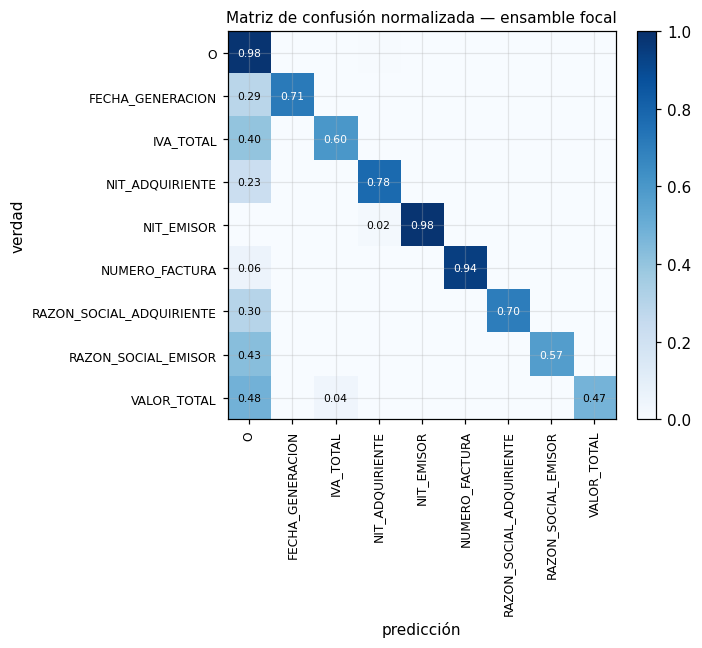


Entropía predictiva media (ensamble): todos los tokens = 0.167 bits | solo tokens-entidad = 0.458 bits (máximo teórico = 4.087 bits)
Lectura: el peso fuera de la diagonal indica si el ensamble CONFUNDE campos entre sí o los manda a
fondo (columna O = no-detección). Entropía baja = ensamble más confiado y mejor calibrado.


In [27]:
# 22. Evaluacion de errores del ENSAMBLE FOCAL: matriz de confusion (nivel entidad) + entropia predictiva.
#     Complementa §20 (tipos de error). Inferencia = promedio de probs de LiLT focal + LayoutLMv3 focal (W=0.5).
import json, numpy as np, torch
import pandas as pd
from PIL import Image
from IPython.display import display
from validar_kie_estadistico import cargar_modelo, MAX_LEN
try:
    import matplotlib.pyplot as plt; HAS_MPL = True
except ImportError:
    HAS_MPL = False

device = 'cuda' if torch.cuda.is_available() else 'cpu'
test   = [json.loads(l) for l in open(f'{DATASET_DIR}/test.jsonl', encoding='utf-8')]
LABELS = open(f'{DATASET_DIR}/labels.txt', encoding='utf-8').read().split()
ENTS   = ['O'] + sorted({l[2:] for l in LABELS if l != 'O'})
ci     = {e: i for i, e in enumerate(ENTS)}
grp    = lambda l: 'O' if l == 'O' else l[2:]
W_ENS  = 0.5

@torch.no_grad()
def _probs(ej, proc, model, ui):
    words, boxes = ej['tokens'], ej['bboxes']
    if ui:
        img = Image.open(ej['image_path']).convert('RGB')
        enc = proc(img, words, boxes=boxes, return_tensors='pt', truncation=True, padding='max_length', max_length=MAX_LEN)
    else:
        enc = proc(words, boxes=boxes, return_tensors='pt', truncation=True, padding='max_length', max_length=MAX_LEN)
    wid = enc.word_ids(0); inp = {k: v.to(device) for k, v in enc.items()}
    p = torch.softmax(model(**inp).logits[0], -1).cpu().numpy()
    col = {l: int(i) for l, i in model.config.label2id.items()}
    P = np.zeros((len(words), len(LABELS))); seen = set()
    for idx, w in enumerate(wid):
        if w is None or w in seen: continue
        seen.add(w); P[w] = [p[idx, col[l]] for l in LABELS]
    return P

def _probs_modelo(mdir):
    proc, model, _, ui = cargar_modelo(mdir, device)
    Ps = [_probs(ej, proc, model, ui) for ej in test]; del model
    if device == 'cuda': torch.cuda.empty_cache()
    return Ps

PLf = _probs_modelo(f'{BASE}/kie_lilt_focal/best')
PVf = _probs_modelo(f'{BASE}/kie_layoutlmv3_focal/best')
Pe  = [W_ENS * pl + (1 - W_ENS) * pv for pl, pv in zip(PLf, PVf)]   # probs del ensamble

yt, yp, ent_all, ent_ent = [], [], [], []
for ej, P in zip(test, Pe):
    pred = [LABELS[i] for i in P.argmax(1)]
    e = -(P * np.log2(np.clip(P, 1e-12, 1))).sum(1)                 # entropia por palabra (bits)
    for tg, pl, ee in zip(ej['ner_tags'], pred, e):
        yt.append(grp(tg)); yp.append(grp(pl)); ent_all.append(float(ee))
        if tg != 'O': ent_ent.append(float(ee))

# --- matriz de confusion (nivel entidad; colapsa B-/I-) ---
M = np.zeros((len(ENTS), len(ENTS)), int)
for tg, pl in zip(yt, yp): M[ci[tg], ci[pl]] += 1
df = pd.DataFrame(M, index=[f'V:{e}' for e in ENTS], columns=[f'P:{e}' for e in ENTS])
dfn = df.div(df.sum(1).replace(0, 1), axis=0)
print('ENSAMBLE FOCAL — Matriz de confusión (conteo de tokens):'); display(df)
print('Normalizada por fila (la diagonal = recall por clase):'); display(dfn.round(3))
if HAS_MPL:
    fig, ax = plt.subplots(figsize=(7, 6))
    im = ax.imshow(dfn.values, vmin=0, vmax=1, cmap='Blues')
    ax.set_xticks(range(len(ENTS))); ax.set_xticklabels(ENTS, rotation=90, fontsize=8)
    ax.set_yticks(range(len(ENTS))); ax.set_yticklabels(ENTS, fontsize=8)
    ax.set_xlabel('predicción'); ax.set_ylabel('verdad')
    ax.set_title('Matriz de confusión normalizada — ensamble focal')
    for i in range(len(ENTS)):
        for j in range(len(ENTS)):
            v = dfn.values[i, j]
            if v > 0.01:
                ax.text(j, i, f'{v:.2f}', ha='center', va='center', fontsize=7, color='white' if v > 0.5 else 'black')
    fig.colorbar(im, fraction=0.046, pad=0.04); plt.tight_layout(); plt.show()

h_all = float(np.nanmean(ent_all)); h_ent = float(np.nanmean(ent_ent))
print(f'\nEntropía predictiva media (ensamble): todos los tokens = {h_all:.3f} bits | solo tokens-entidad = {h_ent:.3f} bits '
      f'(máximo teórico = {np.log2(len(LABELS)):.3f} bits)')
print('Lectura: el peso fuera de la diagonal indica si el ensamble CONFUNDE campos entre sí o los manda a')
print('fondo (columna O = no-detección). Entropía baja = ensamble más confiado y mejor calibrado.')


## 21. Validación cruzada por emisor del ensamble focal

El *gap* de generalización del modelo elegido, medido directamente (re-entrenando sus dos componentes por fold). Complementa el argumento de que el ensamble hereda la generalización de sus partes.

> Decisión — el gap* del ensamble se hereda. Al ser un promedio de probabilidades (reducción de varianza), el ensamble no puede introducir un sobreajuste que sus componentes no tengan; su CV directa es opcional. El argumento se cierra midiendo el gap de ambos modelos base.

> **Entorno: `venv_kie`**

In [ ]:
# 23. VALIDACION CRUZADA por emisor del ENSAMBLE FOCAL (gap CV-prueba).
#     Por cada fold re-entrena LiLT focal + LayoutLMv3 focal sobre los emisores de train restantes,
#     promedia sus probs sobre el fold retenido y calcula el F1 macro del ensamble.
#     5 folds x 2 modelos = 10 reentrenamientos focales (GPU L4, ~5-8 h).
#     Requiere: seccion 5 (ds, LABELS, id2label, label2id, _prep_lilt, _prep_v3, compute_metrics,
#     MODELOS, MAX_LEN, EPOCHS, BATCH, PATIENCE, _EVAL_KEY, _PROC_KEY) y seccion 13 (FocalTrainer, GAMMA).
# [CONSTRUCCION - se ejecuta una sola vez; 10 reentrenamientos focales, varias horas]
import os, json
import pandas as pd
from IPython.display import display

GAP_ENS_CSV = f'{BASE}/cv_gap_ensamble.csv'
F1_TEST = 0.748   # F1 macro del ensamble focal en el test (seccion 4.9)
FORZAR = 0  # 0 = reutiliza el resultado guardado (cv_gap_ensamble.csv); 1 = repite la validacion cruzada
if salida_construccion(GAP_ENS_CSV, FORZAR, que='la validacion cruzada del ensamble focal'):
    cv = pd.read_csv(GAP_ENS_CSV, index_col=0)
    m, sd = cv['f1_macro_ensamble'].mean(), cv['f1_macro_ensamble'].std()
    display(cv)
    print(f'F1 CV (media +/- sd, emisores de train retenidos): {m:.4f} +/- {sd:.4f}')
    print(f'F1 prueba (ensamble focal, 6 emisores reservados): {F1_TEST:.4f}')
    print(f'GAP (CV - prueba): {m - F1_TEST:+.4f}  (~0 => generalizacion estable, sin sobreajuste a plantillas)')
else:
    import re, shutil
    import numpy as np, torch
    from datasets import Dataset
    from transformers import (AutoProcessor, AutoModelForTokenClassification, LayoutXLMTokenizerFast,
                              TrainingArguments, EarlyStoppingCallback)
    from PIL import Image
    from seqeval.metrics import f1_score

    for _n in ['LABELS', 'id2label', 'label2id', '_prep_lilt', '_prep_v3', 'MODELOS', 'MAX_LEN', 'EPOCHS',
               'BATCH', 'PATIENCE', 'FocalTrainer', 'GAMMA', 'compute_metrics', '_EVAL_KEY', '_PROC_KEY']:
        assert _n in globals(), f'Falta {_n}: corre antes la seccion 5 (entrenamiento) y la seccion 13 (focal).'

    K = 5; SEED = 42; W = 0.5
    CVDIR = f'{BASE}/kie_ens_cv'
    train_rows = [json.loads(l) for l in open(f'{DATASET_DIR}/train.jsonl', encoding='utf-8')]
    def _emisor(r):
        if r.get('layout'): return r['layout']
        m = re.match(LAYOUT_REGEX, r['id']); return m.group(1) if m else r['id']
    for r in train_rows: r['_emisor'] = _emisor(r)
    emisores = sorted({r['_emisor'] for r in train_rows})
    rng = np.random.default_rng(SEED); perm = list(rng.permutation(emisores))
    folds = [perm[i::K] for i in range(K)]
    print(f'CV del ENSAMBLE FOCAL: {len(train_rows)} facturas, {len(emisores)} emisores, {K} folds '
          f'(10 reentrenamientos focales; puede tardar horas)')

    def _ds(rows):
        cols = [c for c in rows[0].keys() if c != '_emisor']
        return Dataset.from_list([{c: r[c] for c in cols} for r in rows])

    def _train_focal_fold(nombre, tr_rows, va_rows, outdir):
        """Entrena un modelo focal (nombre='lilt'|'layoutlmv3') en tr_rows; devuelve (proc, model, usa_imagen)."""
        cfg = MODELOS[nombre]
        if cfg['usa_imagen']:
            proc = AutoProcessor.from_pretrained(cfg['ckpt'], apply_ocr=False); prep = _prep_v3(proc)
        else:
            proc = LayoutXLMTokenizerFast.from_pretrained(cfg['tok_ckpt']); prep = _prep_lilt(proc)
        d_tr = _ds(tr_rows); d_va = _ds(va_rows)
        enc_tr = d_tr.map(prep, batched=True, remove_columns=d_tr.column_names); enc_tr.set_format('torch')
        enc_va = d_va.map(prep, batched=True, remove_columns=d_va.column_names); enc_va.set_format('torch')
        model = AutoModelForTokenClassification.from_pretrained(
            cfg['ckpt'], num_labels=len(LABELS), id2label=id2label, label2id=label2id)
        ta = dict(output_dir=outdir, per_device_train_batch_size=BATCH, per_device_eval_batch_size=BATCH,
                  learning_rate=2e-5, num_train_epochs=EPOCHS, warmup_ratio=0.1, weight_decay=0.01,
                  save_strategy='epoch', save_total_limit=1, load_best_model_at_end=True,
                  metric_for_best_model='f1_macro', greater_is_better=True, logging_steps=20,
                  report_to='none', seed=SEED)
        ta[_EVAL_KEY] = 'epoch'
        tk = dict(model=model, args=TrainingArguments(**ta), train_dataset=enc_tr, eval_dataset=enc_va,
                  compute_metrics=compute_metrics, callbacks=[EarlyStoppingCallback(early_stopping_patience=PATIENCE)],
                  gamma=GAMMA)
        tk[_PROC_KEY] = proc
        tr = FocalTrainer(**tk); tr.train()
        return proc, model, cfg['usa_imagen']

    @torch.no_grad()
    def _probs_rows(rows, proc, model, ui):
        dev = model.device; out = []
        for ej in rows:
            words, boxes = ej['tokens'], ej['bboxes']
            if ui:
                img = Image.open(ej['image_path']).convert('RGB')
                enc = proc(img, words, boxes=boxes, return_tensors='pt', truncation=True, padding='max_length', max_length=MAX_LEN)
            else:
                enc = proc(words, boxes=boxes, return_tensors='pt', truncation=True, padding='max_length', max_length=MAX_LEN)
            wid = enc.word_ids(0); inp = {k: v.to(dev) for k, v in enc.items()}
            p = torch.softmax(model(**inp).logits[0], -1).cpu().numpy()
            col = {l: int(i) for l, i in model.config.label2id.items()}
            P = np.zeros((len(words), len(LABELS))); seen = set()
            for idx, w in enumerate(wid):
                if w is None or w in seen: continue
                seen.add(w); P[w] = [p[idx, col[l]] for l in LABELS]
            out.append(P)
        return out

    filas = []
    for f in range(K):
        va = set(folds[f])
        va_rows = [r for r in train_rows if r['_emisor'] in va]
        tr_rows = [r for r in train_rows if r['_emisor'] not in va]
        gold = [r['ner_tags'] for r in va_rows]
        print(f'\n----- Fold {f+1}/{K}: {len(folds[f])} emisores val ({len(va_rows)} fac) / {len(tr_rows)} fac train -----')
        pL, mL, uL = _train_focal_fold('lilt', tr_rows, va_rows, f'{CVDIR}/f{f}_lilt')
        PL = _probs_rows(va_rows, pL, mL, uL); del mL
        if torch.cuda.is_available(): torch.cuda.empty_cache()
        pV, mV, uV = _train_focal_fold('layoutlmv3', tr_rows, va_rows, f'{CVDIR}/f{f}_v3')
        PV = _probs_rows(va_rows, pV, mV, uV); del mV
        if torch.cuda.is_available(): torch.cuda.empty_cache()
        pred = [[LABELS[i] for i in (W * pl + (1 - W) * pv).argmax(1)] for pl, pv in zip(PL, PV)]
        f1m = f1_score(gold, pred, average='macro')
        filas.append({'fold': f+1, 'n_emisores_val': len(folds[f]), 'n_val': len(va_rows), 'f1_macro_ensamble': round(f1m, 4)})
        print(f'  F1 macro (ensamble focal, fold): {f1m:.4f}')
        shutil.rmtree(f'{CVDIR}/f{f}_lilt', ignore_errors=True)
        shutil.rmtree(f'{CVDIR}/f{f}_v3', ignore_errors=True)

    cv = pd.DataFrame(filas).set_index('fold')
    cv.to_csv(GAP_ENS_CSV)
    m, sd = cv['f1_macro_ensamble'].mean(), cv['f1_macro_ensamble'].std()
    print('\n=== Validacion cruzada por emisor - ENSAMBLE FOCAL (5 folds) ===')
    display(cv)
    print(f'F1 CV (media +/- sd, emisores de train retenidos): {m:.4f} +/- {sd:.4f}')
    print(f'F1 prueba (ensamble focal, 6 emisores reservados): {F1_TEST:.4f}')
    print(f'GAP (CV - prueba): {m - F1_TEST:+.4f}  (~0 => generalizacion estable, sin sobreajuste a plantillas)')

## 22. Producción: inferencia + validación (reglas + cruce con BD)

Ante una factura nueva, `inferir_factura.py` aplica el ensamble focal y `reglas_validacion.py` valida en dos capas: reglas deterministas y cruce por CUFE contra la base de referencia (existencia, luego coherencia campo a campo).

> Decisión — validez por campo, sin veredicto. La salida es la validez campo a campo en [0, 1] (COINCIDE/DIFIERE/NO_COMPARABLE): señala qué campo falla y en qué medida, trazable y auditable. El cruce con la base de referencia es por CUFE: existencia, luego coherencia campo a campo.

> **Entorno: `venv_kie`** — producción: inferencia + validación por CUFE sobre facturas.

In [29]:
# 19.a  Inferencia KIE con el MODELO FINAL de produccion: ENSAMBLE FOCAL (LiLT focal + LayoutLMv3 focal).
#       Reutiliza facturas_ocr/ (no re-OCR) y los kie_*_focal/best (no re-entrena) -> pred_kie/<id>.pred.json
# [PRODUCCION - aplica el modelo ya entrenado sobre el lote de facturas]
import subprocess, sys
PRED_DIR = f'{BASE}/pred_kie'
FORZAR = 0  # 0 = reutiliza las predicciones ya generadas; 1 = vuelve a inferir todo el lote
if not salida_construccion(f'{PRED_DIR}/*.pred.json', FORZAR,
                           que='la inferencia del ensamble focal sobre las facturas', fase='produccion'):
    r = subprocess.run([sys.executable, 'inferir_factura.py',
                        '--ocr_dir',  OCR_DIR,
                        '--modelo',   f'{BASE}/kie_lilt_focal/best',
                        '--modelo2',  f'{BASE}/kie_layoutlmv3_focal/best',
                        '--peso',     '0.5',
                        '--salida',   PRED_DIR],
                       capture_output=True, text=True)
    print(r.stdout[-4000:])
    if r.returncode:
        print('STDERR:', r.stderr[-2000:])
    print('[exit', r.returncode, ']')

[Salida ya generada -- fase de produccion. No se vuelve a ejecutar.]
Se reutiliza el resultado de la inferencia del ensamble focal sobre las facturas:
   - /home/jperezv/agente-documentos/pred_kie/*.pred.json
Para volver a ejecutar este proceso, cambia FORZAR de 0 a 1 en esta celda.


In [30]:
# 8.b  Validez POR CAMPO y POR FACTURA (sin veredicto global).
#      Genera los .validacion.json (reglas + cruce por CUFE con la BD) y arma una MATRIZ de validez
#      por campo. Cada factura tiene una validez en [0,1] = (campos que COINCIDEN con la BD) /
#      (campos comparables). Ya NO se clasifica la factura como VALIDA/NO_VALIDA.
# [PRODUCCION - validacion sobre las facturas ya inferidas]
import subprocess, sys, glob, json
import numpy as np, pandas as pd
from IPython.display import display

PRED_DIR = f'{BASE}/pred_kie'
VAL_DIR  = f'{BASE}/validacion'
CAMPOS8  = ['NUMERO_FACTURA', 'FECHA_GENERACION', 'NIT_EMISOR', 'RAZON_SOCIAL_EMISOR',
            'NIT_ADQUIRIENTE', 'RAZON_SOCIAL_ADQUIRIENTE', 'VALOR_TOTAL', 'IVA_TOTAL']

# Genera/actualiza los .validacion.json (la capa de cruce campo-a-campo vive ahi)
FORZAR = 0  # 0 = reutiliza los .validacion.json existentes; 1 = vuelve a correr reglas_validacion.py
if not salida_construccion(f'{VAL_DIR}/*.validacion.json', FORZAR,
                           que='la validacion por campo (reglas + cruce con la BD)', fase='produccion'):
    r = subprocess.run([sys.executable, 'reglas_validacion.py',
                        '--pred_dir', PRED_DIR, '--db', DB_FACTURAS, '--salida', VAL_DIR],
                       capture_output=True, text=True)
    if r.returncode:
        print('STDERR:', r.stderr[-2000:])

# estado del cruce por campo -> validez: 1=COINCIDE, 0=DIFIERE, NaN=NO_COMPARABLE/ausente
EST2VAL = {'COINCIDE': 1.0, 'DIFIERE': 0.0}
filas = []
for fp in sorted(glob.glob(f'{VAL_DIR}/*.validacion.json')):
    v = json.load(open(fp, encoding='utf-8'))
    cr = v.get('cruce') or {}
    estados = {d['campo']: d['estado'] for d in cr.get('campos', [])}
    fila = {'id': v['id'], 'bd_encontrada': cr.get('encontrada', False)}
    for c in CAMPOS8:
        fila[c] = EST2VAL.get(estados.get(c), np.nan)
    comp = [fila[c] for c in CAMPOS8 if not (isinstance(fila[c], float) and np.isnan(fila[c]))]
    fila['validez'] = round(float(np.mean(comp)), 3) if comp else np.nan   # [0,1] por factura
    fila['n_comparables'] = len(comp)
    filas.append(fila)

if filas:
    val = pd.DataFrame(filas).set_index('id')
    print(f'Validez por campo y por factura -- {len(val)} facturas '
          f'({int(val["bd_encontrada"].sum())} encontradas en la BD)')
    print('1 = coincide con la BD, 0 = difiere, vacio = no comparable.')
    print('validez (por factura) = media de los campos comparables (p.ej. 0.8 = 4 de 5 coinciden).\n')
    display(val[['validez', 'n_comparables'] + CAMPOS8])
    print('\n=== Distribucion de la validez por factura ===')
    display(val['validez'].describe().round(3))
else:
    print('No hay .validacion.json (corre antes la celda 8.a para generar pred_kie/).')

[Salida ya generada -- fase de produccion. No se vuelve a ejecutar.]
Se reutiliza el resultado de la validacion por campo (reglas + cruce con la BD):
   - /home/jperezv/agente-documentos/validacion/*.validacion.json
Para volver a ejecutar este proceso, cambia FORZAR de 0 a 1 en esta celda.
Validez por campo y por factura -- 620 facturas (600 encontradas en la BD)
1 = coincide con la BD, 0 = difiere, vacio = no comparable.
validez (por factura) = media de los campos comparables (p.ej. 0.8 = 4 de 5 coinciden).



,validez,n_comparables,NUMERO_FACTURA,FECHA_GENERACION,NIT_EMISOR,RAZON_SOCIAL_EMISOR,NIT_ADQUIRIENTE,RAZON_SOCIAL_ADQUIRIENTE,VALOR_TOTAL,IVA_TOTAL
id,,,,,,,,,,
layout_01_001,0.833,6,1.0,1.0,1.0,NaN,1.0,1.0,0.0,NaN
layout_01_002,0.667,6,1.0,1.0,0.0,NaN,1.0,1.0,0.0,NaN
layout_01_003,0.833,6,1.0,1.0,1.0,NaN,1.0,1.0,0.0,NaN
layout_01_004,0.667,6,1.0,1.0,0.0,NaN,1.0,1.0,0.0,NaN
layout_01_005,0.833,6,1.0,1.0,1.0,NaN,1.0,1.0,0.0,NaN
...,...,...,...,...,...,...,...,...,...,...
layout_30_016,1.000,7,1.0,1.0,1.0,1.0,1.0,1.0,1.0,NaN
layout_30_017,1.000,7,1.0,1.0,1.0,1.0,1.0,1.0,1.0,NaN
layout_30_018,1.000,7,1.0,1.0,1.0,1.0,1.0,1.0,1.0,NaN



=== Distribucion de la validez por factura ===


count    600.000
mean       0.804
std        0.184
min        0.250
25%        0.750
50%        0.833
75%        1.000
max        1.000
Name: validez, dtype: float64

### 22.1 Estadísticas descriptivas de la validez por campo

Fiabilidad por campo y distribución de la validez por factura, a partir de la matriz de la celda anterior.

> **Entorno: `venv_kie`**

In [31]:
# 8.c  Estadisticas descriptivas de la validez por campo (sobre la matriz `val` de la celda 8.b)
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

assert 'val' in globals(), 'Corre antes la celda 8.b (define `val` y `CAMPOS8`).'

# --- (i) Fiabilidad por campo: % de facturas comparables en que el campo COINCIDE con la BD ---
rel = pd.DataFrame({
    'coincide':      (val[CAMPOS8] == 1).sum(),
    'difiere':       (val[CAMPOS8] == 0).sum(),
    'no_comparable': val[CAMPOS8].isna().sum(),
})
rel['comparables'] = rel['coincide'] + rel['difiere']
rel['%_validez'] = (rel['coincide'] / rel['comparables'].replace(0, np.nan) * 100).round(1)
rel = rel.sort_values('%_validez', ascending=False)
print('=== Fiabilidad por campo (de mayor a menor validez) ===')
display(rel)

# --- (ii) Validez por factura ---
vv = val['validez'].dropna()
print('\n=== Validez por factura ===')
print(f'facturas con campos comparables: {len(vv)} de {len(val)}')
print(f'media: {vv.mean():.3f} | mediana: {vv.median():.3f} | std: {vv.std():.3f} '
      f'| min: {vv.min():.3f} | max: {vv.max():.3f}')
print(f'facturas 100% validas (validez = 1.0): {(vv == 1.0).sum()} ({(vv == 1.0).mean()*100:.1f}%)')
print(f'facturas con alguna discrepancia (validez < 1.0): {(vv < 1.0).sum()}')

print('\n=== Conteo por nivel de validez ===')
display(vv.round(2).value_counts().sort_index(ascending=False).to_frame('n_facturas'))

# --- Graficas ---
fig, ax = plt.subplots(1, 2, figsize=(12, 3.6))
vv.plot.hist(bins=np.linspace(0, 1, 11), ax=ax[0], color='seagreen', edgecolor='white')
ax[0].set_title('Distribucion de la validez por factura'); ax[0].set_xlabel('validez [0,1]'); ax[0].set_ylabel('facturas')
ax[0].bar_label(ax[0].containers[0], labels=[int(v) if v else '' for v in ax[0].containers[0].datavalues], fontsize=8)
rel['%_validez'].plot.barh(ax=ax[1], color='steelblue'); ax[1].invert_yaxis()
ax[1].set_title('% de validez por campo'); ax[1].set_xlim(0, 112); ax[1].set_xlabel('% validez')
for _y, _v in enumerate(rel['%_validez'].values):
    if _v == _v:  # omite NaN (campos sin comparables)
        ax[1].text(_v + 1.5, _y, f'{_v:.0f}', va='center', fontsize=8)
plt.tight_layout(); plt.show()


=== Fiabilidad por campo (de mayor a menor validez) ===


,coincide,difiere,no_comparable,comparables,%_validez
FECHA_GENERACION,441,3,176,444,99.3
NUMERO_FACTURA,572,21,27,593,96.5
NIT_EMISOR,532,26,62,558,95.3
NIT_ADQUIRIENTE,502,45,73,547,91.8
RAZON_SOCIAL_ADQUIRIENTE,458,91,71,549,83.4
RAZON_SOCIAL_EMISOR,380,160,80,540,70.4
VALOR_TOTAL,75,270,275,345,21.7
IVA_TOTAL,40,200,380,240,16.7



=== Validez por factura ===
facturas con campos comparables: 600 de 620
media: 0.804 | mediana: 0.833 | std: 0.184 | min: 0.250 | max: 1.000
facturas 100% validas (validez = 1.0): 179 (29.8%)
facturas con alguna discrepancia (validez < 1.0): 421

=== Conteo por nivel de validez ===


,n_facturas
validez,
1.00,179
0.86,70
0.83,65
0.80,78
0.75,69
0.71,43
0.67,8
0.60,8
0.50,42


## 23. EDA 4 · Resultados del modelo final en producción

El cuarto EDA, gemelo de los tres de entrada pero sobre la salida: precisión/exhaustividad/F1 por entidad, completitud por factura, desempeño por emisor de test y tipos de error del ensamble focal (el modelo de producción) sobre emisores no vistos.

> **Entorno: `venv_kie`**

In [ ]:
# 20. EDA de resultados del modelo de produccion (ENSAMBLE FOCAL) sobre el test de emisores no vistos.
#     Inferencia = promedio de probabilidades por palabra de LiLT focal + LayoutLMv3 focal (W=0.5).
#     (1) P/R/F1 por entidad  (2) completitud por factura sobre campos PRESENTES (denom. variable)
#     (3) completitud media por emisor de test  (4) tipos de error por entidad. Solo inferencia.
import numpy as np, torch, json, evaluate
from collections import defaultdict
import pandas as pd, matplotlib.pyplot as plt
from PIL import Image
from IPython.display import display
from validar_kie_estadistico import cargar_modelo, MAX_LEN

device = 'cuda' if torch.cuda.is_available() else 'cpu'
test   = [json.loads(l) for l in open(f'{DATASET_DIR}/test.jsonl', encoding='utf-8')]
LABELS = open(f'{DATASET_DIR}/labels.txt', encoding='utf-8').read().split()
ENTS   = sorted({l[2:] for l in LABELS if l != 'O'})
gold   = [ej['ner_tags'] for ej in test]
seqeval = evaluate.load('seqeval')
W_ENS  = 0.5

@torch.no_grad()
def _probs(ej, proc, model, ui):
    words, boxes = ej['tokens'], ej['bboxes']
    if ui:
        img = Image.open(ej['image_path']).convert('RGB')
        enc = proc(img, words, boxes=boxes, return_tensors='pt', truncation=True, padding='max_length', max_length=MAX_LEN)
    else:
        enc = proc(words, boxes=boxes, return_tensors='pt', truncation=True, padding='max_length', max_length=MAX_LEN)
    wid = enc.word_ids(0); inp = {k: v.to(device) for k, v in enc.items()}
    p = torch.softmax(model(**inp).logits[0], -1).cpu().numpy()
    col = {l: int(i) for l, i in model.config.label2id.items()}
    P = np.zeros((len(words), len(LABELS))); seen = set()
    for idx, w in enumerate(wid):
        if w is None or w in seen: continue
        seen.add(w); P[w] = [p[idx, col[l]] for l in LABELS]
    return P

def _probs_modelo(mdir):
    proc, model, _, ui = cargar_modelo(mdir, device)
    Ps = [_probs(ej, proc, model, ui) for ej in test]
    del model
    if device == 'cuda': torch.cuda.empty_cache()
    return Ps

# --- ENSAMBLE FOCAL (modelo de produccion): promedio de probs de los dos modelos focales ---
PL = _probs_modelo(f'{BASE}/kie_lilt_focal/best')
PV = _probs_modelo(f'{BASE}/kie_layoutlmv3_focal/best')
pred = [[LABELS[i] for i in (W_ENS * pl + (1 - W_ENS) * pv).argmax(1)] for pl, pv in zip(PL, PV)]

def _spans(tags):
    d = defaultdict(set); i, n = 0, len(tags)
    while i < n:
        if tags[i].startswith('B-'):
            e = tags[i][2:]; j = i + 1
            while j < n and tags[j] == 'I-' + e: j += 1
            d[e].add((i, j)); i = j
        else: i += 1
    return d

# (1) P/R/F1 por entidad
r = seqeval.compute(predictions=pred, references=gold, zero_division=0)
dfent = pd.DataFrame({e: {'precisión': r[e]['precision'], 'exhaustividad': r[e]['recall'],
                          'f1': r[e]['f1'], 'soporte': r[e]['number']} for e in ENTS}).T
print(f"ENSAMBLE FOCAL | F1 macro {np.mean([r[e]['f1'] for e in ENTS]):.3f} | F1 micro {r['overall_f1']:.3f}\n")
display(dfent.round(3))

# (2) completitud por factura sobre campos PRESENTES (denominador variable)
filas = []
for ej, pt, gt in zip(test, pred, gold):
    sp, sg = _spans(pt), _spans(gt)
    presentes = [e for e in ENTS if sg.get(e)]
    correctos = sum(1 for e in presentes if sp.get(e, set()) == sg.get(e, set()))
    comp = correctos / len(presentes) if presentes else np.nan
    filas.append({'layout': ej['layout'], 'presentes': len(presentes), 'correctos': correctos, 'completitud': comp})
dfc = pd.DataFrame(filas)
print(f"\nCompletitud por factura (sobre campos presentes): media {dfc['completitud'].mean()*100:.1f} % | "
      f"mediana {dfc['completitud'].median()*100:.1f} %")
print(f"Campos presentes por factura: media {dfc['presentes'].mean():.2f} (rango {dfc['presentes'].min()}-{dfc['presentes'].max()}; no siempre 8)")

# (3) completitud media por emisor (layout) de test
porlay = dfc.groupby('layout')['completitud'].mean().mul(100).sort_values()

# (4) tipos de error por entidad
err = {e: {'ok': 0, 'no_detectado': 0, 'confundido': 0, 'falso_positivo': 0} for e in ENTS}
for pt, gt in zip(pred, gold):
    sp, sg = _spans(pt), _spans(gt)
    for e in ENTS:
        for s in sg.get(e, set()):
            if s in sp.get(e, set()): err[e]['ok'] += 1
            elif any(s in sp.get(o, set()) for o in ENTS if o != e): err[e]['confundido'] += 1
            else: err[e]['no_detectado'] += 1
        for s in sp.get(e, set()):
            if s not in sg.get(e, set()) and not any(s in sg.get(o, set()) for o in ENTS if o != e):
                err[e]['falso_positivo'] += 1
dferr = pd.DataFrame(err).T

# --- graficas ---
fig, ax = plt.subplots(2, 2, figsize=(15, 9))
fig.suptitle('EDA — Ensamble focal (producción) sobre el test (emisores no vistos)', fontweight='bold', fontsize=13)
dfent[['precisión', 'exhaustividad', 'f1']].plot.barh(ax=ax[0, 0]); ax[0, 0].set_xlim(0, 1)
ax[0, 0].set_title('Precisión / exhaustividad / F1 por entidad'); ax[0, 0].invert_yaxis(); ax[0, 0].set_xlabel('valor')
for _c in ax[0, 0].containers:
    ax[0, 0].bar_label(_c, fmt='%.2f', fontsize=5.5, padding=1)
dfc['completitud'].mul(100).plot.hist(bins=np.linspace(0, 100, 11), ax=ax[0, 1], color='seagreen', edgecolor='white')
ax[0, 1].set_title('Completitud por factura (% de campos presentes correctos)'); ax[0, 1].set_xlabel('%'); ax[0, 1].set_ylabel('facturas')
ax[0, 1].bar_label(ax[0, 1].containers[0], fontsize=8)
porlay.plot.barh(ax=ax[1, 0], color='steelblue'); ax[1, 0].set_xlim(0, 112)
for _y, _v in enumerate(porlay.values):
    ax[1, 0].text(_v + 1.5, _y, f'{_v:.0f}', va='center', fontsize=8)
ax[1, 0].set_title('Completitud media por emisor de test'); ax[1, 0].set_xlabel('%')
dferr[['no_detectado', 'confundido', 'falso_positivo']].plot.bar(stacked=True, ax=ax[1, 1],
        color=['#d62728', '#e8a33d', '#9467bd']); ax[1, 1].set_title('Tipos de error por entidad'); ax[1, 1].set_ylabel('spans (gold)'); ax[1, 1].tick_params(axis='x', rotation=40)
for _c in ax[1, 1].containers:
    ax[1, 1].bar_label(_c, label_type='center', fontsize=7, labels=[int(v) if v else '' for v in _c.datavalues])
plt.tight_layout(rect=[0, 0, 1, 0.96]); plt.show()

print('\n=== Tipos de error por entidad (sobre spans del gold; falso_positivo = predicho de más) ===')
display(dferr)
